# Connectomics Module 2a: Network connectivity

Until now we have focused on one neuron and its inputs and outputs. However, the power of this method comes from looking at neurons embedded in their connectivity networks. Which neurons connect to which other neuron types, whether that input and output relationship is symmetric, and if it is not symmetric what that structure tells us about function. 

Module 2a of this workshop will:

* introduce concepts of network connectivity
* investigate the role of cell type in the structure of networks

Module 2b, after the break, will:

* consider connection probability as a function of distance
* incorporate ophys recordings and map the correlation of structure to function

## Setup

Where the data lives depends on where you are running: `/data/` on CodeOcean, the
Brain2026 drive at the workshop, a `data/` folder in a local checkout. `utils/paths.py`
walks that ladder — `SWDB_DATA_ROOT` if you set it, then a repo-local `data/`, then the
platform default — and fails with the list of paths it tried if none exist. Read its
docstring if a path ever surprises you.

In [ ]:
import sys
from os.path import join as pjoin
from typing import Optional, Union

mat_version = 1196

# Identifiers within the Common Connectivity dataset
project_id = "v1dd"
synapse_dataset_id = f"v1dd_{mat_version}_em"
synapse_feature_matrix_id = f"v1dd_{mat_version}_synapse_features"
axon_dataset_id = f"v1dd_{mat_version}_proofread_axons"
dendrite_dataset_id = f"v1dd_{mat_version}_proofread_dendrites"

sys.path.append(pjoin("..", "utils"))

import itertools

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import tqdm
from connects_common_connectivity.io import DatasetReader, read_synapse_table
from matplotlib import pyplot as plt
from scipy import spatial, stats
from scipy.sparse import csr_array

from paths import resolve_data_root, resolve_dataset_dir

data_root = resolve_data_root(f"v1dd_{mat_version}_ccm")

# The EM side: cells, cell types and synapses, in Common Connectivity format
ccm_dir = resolve_dataset_dir(f"v1dd_{mat_version}_ccm", root=data_root)

# The two-photon side: its own dataset on CodeOcean, but it sits next to the older feather
# tables if you downloaded those together. Accept either.
functional_dir = resolve_dataset_dir(
    f"v1dd_{mat_version}_coreg_functional_correlation",
    f"v1dd_{mat_version}",
    root=data_root,
)

print(f"ccm_dir        {ccm_dir}")
print(f"functional_dir {functional_dir}")

## Common Connectivity dataset setup

Initialize a Common Connectivity `DatasetReader` for the mounted V1DD dataset.
Each Common Connectivity "dataset" is just a collection of "dataitems" which are neurons in our case.

In [3]:
# Initialize the Common Connectivity dataset reader
reader = DatasetReader(ccm_dir)
reader.display_dataset_names() # see available cohorts

id,name,project_id,modality
str,str,str,str
"""v1dd_1196_em""","""V1DD release 1196 — EM somas""","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_axons""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_dendrites""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""


## Proofreading and data quality

Understanding the variability in data quality is critical when interpreting electron microscopy reconstructions.

Automated segmentation of neuronal processes in dense EM imaging is challenging at the size of entire neurons, which can have millimeters of axons and dendrites. The automated segmentation algorithms used in the EM data for this project are not perfect, and so proofreading is necessary to obtain accurate reconstructions of a cell and confidence in the connectivity.

In general, the **dendrites** of single-soma detected neurons are considered trustworthy, even without proofreading. However the **axons** require manual effort to both clean and extend.

For details on the proofreading status see:

* `code/supplement/etl_v1dd_01_cave_dataset_celltypes.ipynb` for how the data we use today was generated
* Proofreading page in the [SWDB databook](https://allenswdb.github.io/anatomy/microns-em/proofreading.html)

Load the prepared variables: `dendrite_proof_root_ids` and `axon_proof_root_ids`.

In [4]:
# Loads cells with axon and dendrite proofreading
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

dendrite_proof_root_ids = proofread_dendrites[
    "dataitem_id"
].cast(pl.UInt64).to_numpy()
axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()

print(
    f"There are {len(dendrite_proof_root_ids)} cells with acceptable dendrites, and {len(axon_proof_root_ids)} cells with axon proofreading"
)

There are 63986 cells with acceptable dendrites, and 1164 cells with axon proofreading


In [5]:
proofread_axons.head()

dataitem_id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,soma_voxel_x,soma_voxel_y,soma_voxel_z,soma_transformed_x,soma_transformed_y,soma_transformed_z,soma_volume,v1dd_cell_types_level_0,v1dd_cell_types_level_1,v1dd_cell_types_level_2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,str,str,str
"""864691132534275418""",224.539952,228.434194,1.278639,19.476042,0.085259,0.456255,492.136677,612.704786,0.957844,2.03256,0.040803,739373.0,633371.0,323640.0,-0.148078,0.332191,0.03944,224.683212,"""neuron""","""E""","""L4-IT"""
"""864691132534315610""",236.506655,246.509254,1.332867,27.856331,0.113003,0.422036,560.394755,691.239539,1.293702,2.102883,0.088247,823103.0,635932.0,272970.0,-0.062356,0.320556,-0.010524,236.639908,"""neuron""","""E""","""L4-IT"""
"""864691132535664474""",300.20032,264.670537,1.220714,3.614023,0.013655,0.397125,755.934198,923.133835,0.524689,2.300336,0.080162,972173.0,1.006782e6,429480.0,-0.041443,0.739149,0.007656,300.366089,"""neuron""","""E""","""L6-CT"""
"""864691132536286810""",278.67367,330.243349,1.600612,79.708442,0.241363,0.38174,730.008386,707.65966,1.442203,1.804908,0.240228,860041.0,818137.0,270495.0,-0.066701,0.499938,-0.063437,278.909668,"""neuron""","""I""","""DTC"""
"""864691132536904794""",null,null,null,null,null,null,null,null,null,null,null,940822.0,738674.0,146565.0,0.041854,0.385942,-0.158126,273.808777,"""neuron""","""I""","""DTC"""


## Synapse information

While synapses are stored as any other CAVE table in the database, in this case `synapses_v1dd`, this table is much larger than any other table at almost **640 million rows**, and it works best when queried in a directed way.

For today's workshop we have collected all of the input and output synapses for the proofread cells. When accessing CAVE, the `synapse_query()` function allows you to query the synapse table in a more convenient way than most other tables. In particular, the `pre_ids` and `post_ids` let you specify which root id (or collection of root ids) you want to query, with `pre_ids` indicating the collection of presynaptic neurons and `post_ids` the collection of postsynaptic neurons.

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons.

A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them.

### Load the table of connections between proofread cells

The table contains about **8 million entries**.

In [6]:
synapse_data = read_synapse_table(
    project_id,
    dataset_id=synapse_dataset_id,
    features=True,
    feature_matrix_id=synapse_feature_matrix_id,
    output_root=ccm_dir,
)

target_structure = (
    synapse_data.select(pl.col("id").cast(pl.UInt64), "synaptictargetlabel")
    .to_pandas()
    .set_index("id")["synaptictargetlabel"]
)

syn_df = (
    synapse_data.with_columns(
        pl.col("id").cast(pl.UInt64),
        pl.col("presynaptic_cell").cast(pl.UInt64),
        pl.col("postsynaptic_cell").cast(pl.UInt64),
    )
    .rename(
        {
            "presynaptic_cell": "pre_pt_root_id",
            "postsynaptic_cell": "post_pt_root_id",
        }
    )
    .select(
        [
            "id",
            "pre_pt_position_x",
            "pre_pt_position_y",
            "pre_pt_position_z",
            "post_pt_position_x",
            "post_pt_position_y",
            "post_pt_position_z",
            "ctr_pt_position_x",
            "ctr_pt_position_y",
            "ctr_pt_position_z",
            "size",
            "pre_pt_root_id",
            "post_pt_root_id",
        ]
    )
    .to_pandas()
)

print(syn_df.shape)

syn_df.head(3)

(8204497, 13)


,id,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,pre_pt_root_id,post_pt_root_id
0,354386968,758200.5,802316.1,304380.0,757861.0,802558.6,304650.0,757967.7,802597.4,304380.0,240,864691132536286810,864691132734919083
1,378070488,792063.2,514342.5,183735.0,792664.6,514284.3,183915.0,792412.4,514294.0,183735.0,3056,864691132572190492,864691132606767301
2,499493001,977071.3,390075.8,191340.0,976974.3,390104.9,190935.0,976838.5,390337.7,190935.0,1346,864691132573738810,864691132747578447


In [7]:
synapse_data.head()

project_id,id,presynaptic_cell,postsynaptic_cell,dataset_id,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z,size,synaptictargetlabel
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str
"""v1dd""","""354386968""","""864691132536286810""","""864691132734919083""","""v1dd_1196_em""",758200.5,802316.1,304380.0,757861.0,802558.6,304650.0,757967.7,802597.4,304380.0,240,"""shaft"""
"""v1dd""","""378070488""","""864691132572190492""","""864691132606767301""","""v1dd_1196_em""",792063.2,514342.5,183735.0,792664.6,514284.3,183915.0,792412.4,514294.0,183735.0,3056,"""shaft"""
"""v1dd""","""499493001""","""864691132573738810""","""864691132747578447""","""v1dd_1196_em""",977071.3,390075.8,191340.0,976974.3,390104.9,190935.0,976838.5,390337.7,190935.0,1346,null
"""v1dd""","""119675985""","""864691132572564252""","""864691132654028028""","""v1dd_1196_em""",444260.0,602544.6,3285.0,443988.4,602311.8,3555.0,444182.4,602370.0,3780.0,3637,null
"""v1dd""","""220616943""","""864691132558380553""","""864691132828255906""","""v1dd_1196_em""",574501.9,337249.6,258570.0,574152.7,337016.8,258570.0,574337.0,336900.4,258570.0,420,null


This table has a number of columns. We will highlight the most important:

* **`id`:** a unique ID for each synapse
* **`presynaptic_cell`:** the unique ID of the presynaptic compartment. This is equivalent to `pre_pt_root_id` in the CAVEquery
* **`postsynaptic_cell`:** the unique ID of the postsynaptic compartment. This is equivalent to `post_pt_root_id` in the CAVEquery
* **`size`:** a measure of the synapse size (the number of 9, 9, 45 nm voxels in the synapse mask) and the best available metric of synaptic weight
* **`ctr_pt_position_{x,y,z}`:** the location of the synapse in the cleft, stored here in nanometers
* **`pre_pt_position_{x,y,z}`:** a point just in the presynaptic compartment of the synapse (used to look up `pre_root_id`), stored here in nanometers
* **`post_pt_position_{x,y,z}`:** a point just in the postsynaptic compartment of the synapse (used to look up `post_pt_root_id`), stored here in nanometers

Here we define a convenience function for robustly filtering the synapse table by presynaptic or postsynaptic partners. You will use this through the rest of the exercises.

In [8]:
def filter_synapse_table(
    synapse_table: pd.DataFrame, pre_root_ids=None, post_root_ids=None
):
    """Filter synapse table by pre and post root ids.

    Args:
        synapse_table: synapse table with pre_pt_root_ids and post_pt_root_ids as pd.DataFrame
        pre_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the presynaptic side
        post_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the postsynaptic side

    Returns:
        synapse_table: filtered synapse table
    """

    if pre_root_ids is not None:
        assert isinstance(pre_root_ids, (np.ndarray, list, pd.core.series.Series)), (
            f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        )
        pre_mask = np.isin(synapse_table["pre_pt_root_id"], pre_root_ids)
    else:
        pre_mask = np.ones(len(synapse_table), dtype=bool)

    if post_root_ids is not None:
        assert isinstance(post_root_ids, (np.ndarray, list, pd.core.series.Series)), (
            f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        )
        post_mask = np.isin(synapse_table["post_pt_root_id"], post_root_ids)
    else:
        post_mask = np.ones(len(synapse_table), dtype=bool)

    return synapse_table[pre_mask & post_mask]


## Synapse matrix

The synapses between neurons create a network of synaptic connections. One way of visualizing this connectivity is in matrix form.

For now, we will limit ourselves to the synapses between the proofread neurons.

In [8]:
# get the ids of all proofread cells with both axon and dendrite proofreading
proof_root_ids = axon_proof_root_ids[
    np.isin(axon_proof_root_ids, dendrite_proof_root_ids)
]

# filter for synapses between the proofread cells (pre and post)
proof_proof_syn_table = filter_synapse_table(
    syn_df, pre_root_ids=proof_root_ids, post_root_ids=proof_root_ids
)

Next we will make an **adjacency plot** from the tabular synapse data, turning it into a matrix that describes the connection strength between all possible partners. For convenience, we have provided a function `make_adjacency` to perform the ordered groupbys and aggregations.

In [9]:
from utils import check_index


def make_adjacency(
    synapses,
    source_cell_index: Union[pd.Index, pd.DataFrame, pd.Series, np.ndarray, list],
    target_cell_index: Optional[
        Union[pd.Index, pd.DataFrame, pd.Series, np.ndarray, list]
    ] = None,
    aggfunc="binary",
    return_as="dense",
) -> Union[csr_array, np.ndarray]:
    source_cell_index = check_index(source_cell_index)
    if target_cell_index is None:
        target_cell_index = source_cell_index
    else:
        target_cell_index = check_index(target_cell_index)
    synapses = synapses.query(
        "pre_pt_root_id in @source_cell_index and post_pt_root_id in @target_cell_index"
    )
    groupby = synapses.groupby(["pre_pt_root_id", "post_pt_root_id"])
    if aggfunc == "count":
        edges = groupby.size().rename("weight").reset_index()
    elif aggfunc == "binary":
        edges = groupby.size().transform(lambda x: x > 0).rename("weight").reset_index()
    else:
        edges = groupby["size"].agg(aggfunc).rename("weight").reset_index()
    # make sure that the adjacency matrix is sorted the same as the input cell index
    edges["source_index"] = source_cell_index.get_indexer(edges["pre_pt_root_id"])
    edges["target_index"] = target_cell_index.get_indexer(edges["post_pt_root_id"])
    adjacency = csr_array(
        (edges["weight"], (edges["source_index"], edges["target_index"])),
        shape=(len(source_cell_index), len(target_cell_index)),
        dtype=edges["weight"].dtype,
    )
    # NOTE: for many applications working with sparse matrices is more efficient
    # but for ease of use and visualization in this workshop we return a dense matrix
    if return_as == "dense":
        adjacency = adjacency.todense()
    elif return_as == "sparse":
        pass  # already in sparse format
    else:
        raise ValueError(f"Unknown return_as type: {return_as}")
    return adjacency


Each synapse has a `size` value assigned to it. How to aggregate the sizes from multiple synapes between two neurons depends on the research question. Synapse sizes vary by a lot and are related to the physiological strength of a synapse ([Holler et al., 2021](https://www.nature.com/articles/s41586-020-03134-2)).

First, we will ignore the synapse size and strength and only look at **binary (connected yes/no) connectivity**. There are other measures of connectivity you can explore below that change how the network appears.

In [32]:
syn_mat = make_adjacency(proof_proof_syn_table, proof_root_ids, aggfunc="binary")
syn_mat

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False]],
      shape=(1148, 1148))

It looks like many of the values in the adjacency matrix array are `False`. In other words, most of the neurons in the proofread dataset are not connected to each other. How can we look at the places where there are connections? We can use the `np.nonzero()` function to get the indices of the non-zero (`True`) values in the array.

In [11]:
# show the first 10 nonzero values in the array
row_indices, column_indices = np.nonzero(syn_mat)
print("Row indices:", row_indices[:10])
print("Column indices:", column_indices[:10])
print("Matrix values:", syn_mat[row_indices[:10], column_indices[:10]])

Row indices: [0 0 0 0 0 0 0 0 0 0]
Column indices: [118 234 251 262 269 275 393 423 465 579]
Matrix values: [ True  True  True  True  True  True  True  True  True  True]


#### Discussion

What does it mean that all of the first 10 values we looked at share the same row index?

Now, let's move on to plotting the entire matrix.

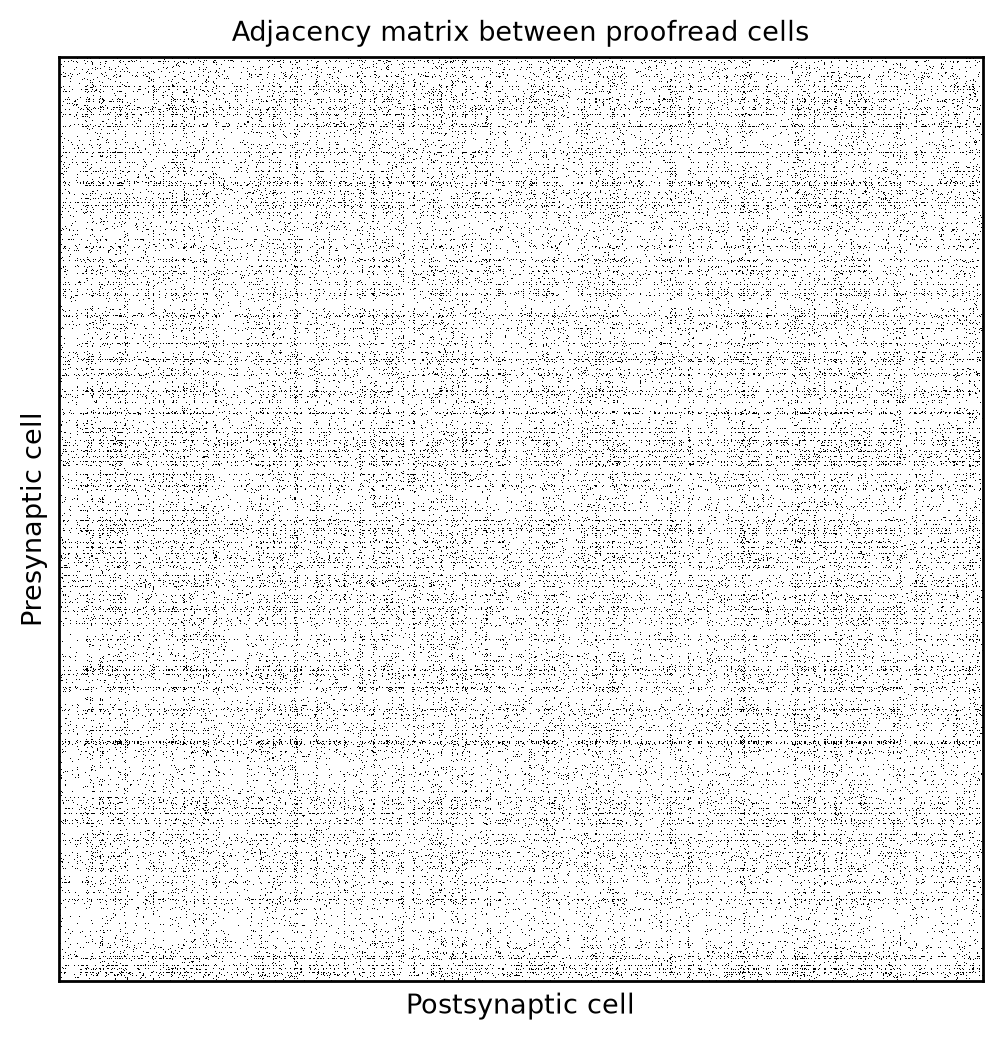

In [12]:
sns.set_context("paper", font_scale=1.0)


fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

sns.heatmap(
    syn_mat,
    cbar=False,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    ax=ax,
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell",
    ylabel="Presynaptic cell",
    title="Adjacency matrix between proofread cells",
)

In [13]:
n_edges = len(row_indices)
n_possible_edges = syn_mat.shape[0] * syn_mat.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

Number of edges: 90845
Number of possible edges: 1317904
Fraction of possible edges: 0.0689


#### Task 3: Rectangular connectivity matrix

The matrix above only contains connections between **axon-proofread neurons**. Because many more dendrites of cells in the V1DD dataset are well-reconstructed, **we can consider more connections than just the ones between proofread neurons.** Therefore, the connectivity matrix of analyzable connections forms a rectangular matrix.

What is the size of the matrix between the proofread neurons and all neurons with a cell body in the dataset?

In [15]:
# Select synapses from proofread cells onto all cells
proof_all_syn_table = filter_synapse_table(
    syn_df, pre_root_ids=axon_proof_root_ids, post_root_ids=dendrite_proof_root_ids
)

print(len(proof_all_syn_table))

# make adjanceny matrix from proofread cells onto all cells
rect_syn_mat = make_adjacency(
    syn_df,
    source_cell_index=axon_proof_root_ids,
    target_cell_index=dendrite_proof_root_ids,
)

# print shape of the matrix
rect_syn_mat.shape

1431746


(1164, 63986)

### Consider: Different measures of synaptic strength

When creating a connectivity matrix, how you measure synaptic strength can make a difference in your analysis. For EM data there are three common ways of reporting connection strength:

1. **Binary connectivity:** whether two cells are connected at all, as shown above.
2. **Synaptic count:** the total number of synapses that are part of the connection. This is typical of the fly connectome, where `count` captures much of the connection diversity. The modal `count` in mouse cortex is much lower.
3. **Synaptic size:** the size of the postsynaptic density at every connection, generally aggregated as `sum` or `mean` for each unique connection.

How to take synapse size and number into account depends on the specific analysis.

The `size` reported in the V1DD dataset measures the synaptic cleft as segmented by the automated classifier in voxels (3D pixels, a measure of volume). These are correlated to anatomical measures such as synaptic area and spine head volumes (for excitatory synapses).

Let's replot the **square matrix** with the `sum` of synapse sizes between each connected pair.

In [34]:
# get the ids of all proofread cells (same as for the binary connectivity)
proof_root_ids = axon_proof_root_ids[
    np.isin(axon_proof_root_ids, dendrite_proof_root_ids)
]

# Now with the aggregation function set to 'mean' synapse size
syn_mat = make_adjacency(syn_df, source_cell_index=proof_root_ids, aggfunc="sum")

# show the first 10 nonzero values in the array
row_indices, column_indices = np.nonzero(syn_mat)
print("Row indices:", row_indices[:10])
print("Column indices:", column_indices[:10])
print("Matrix values:", syn_mat[row_indices[:10], column_indices[:10]])

Row indices: [0 0 0 0 0 0 0 0 0 0]
Column indices: [118 234 251 262 269 275 393 423 465 579]
Matrix values: [2620  898 3828 4488 1556 4965 1436  631  270 3425]


The matrix values are now the **sum of size** rather than `True`/`False`. It is useful to understand the full range of synaptic strength represented, plotted below first on a linear axis and then on a log axis.

[Text(0.5, 0, 'Sum synapse size (voxels - log scale)'),
 Text(0, 0.5, 'Number of connections')]

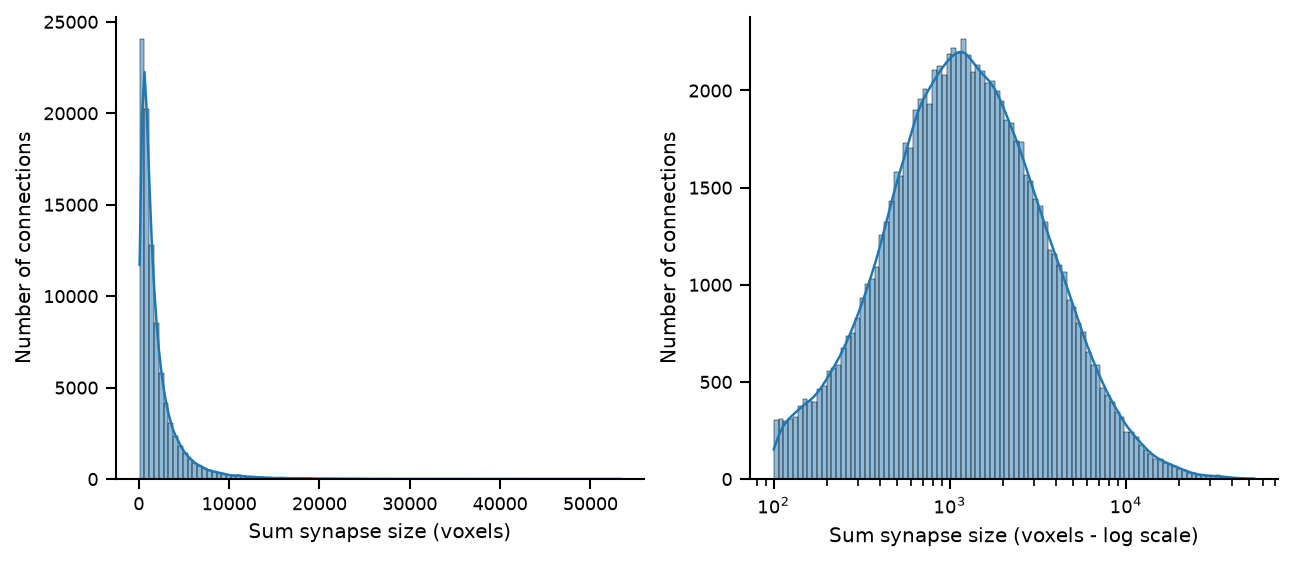

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# collect the synaptic weights that are non-zero
edge_weights = syn_mat[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")

Replot the square matrix with the `sum` of synapse size.

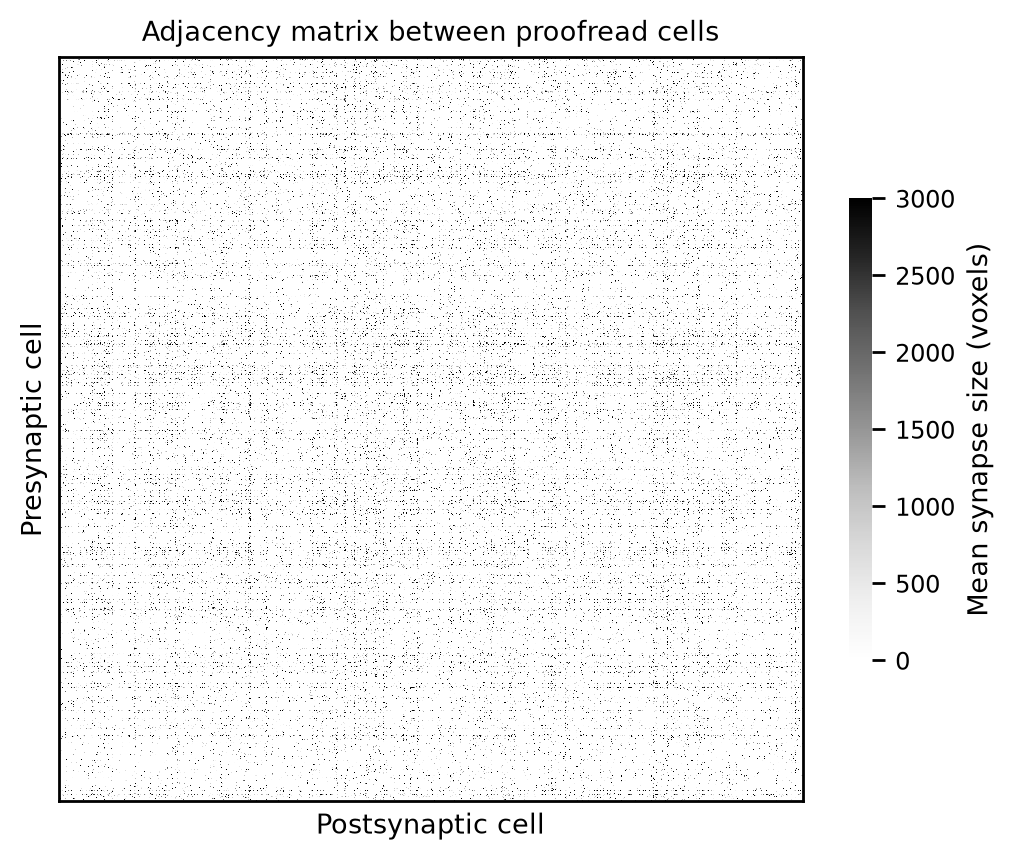

In [36]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
sns.heatmap(
    syn_mat,
    cbar=True,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    vmax=3000,  # set the upper bound on color scale so that we can see more edges
    ax=ax,
    cbar_kws={"label": "Mean synapse size (voxels)", "shrink": 0.5},
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell",
    ylabel="Presynaptic cell",
    title="Adjacency matrix between proofread cells",
)

Depending on the connection type, number of synapses might be the more important measure (see [Dorkenwald et al., 2022](https://elifesciences.org/articles/76120) for a deeper dive into synapse size and counts).

[Text(0.5, 0, 'Number of synapses per connection'),
 Text(0, 0.5, 'Number of connections')]

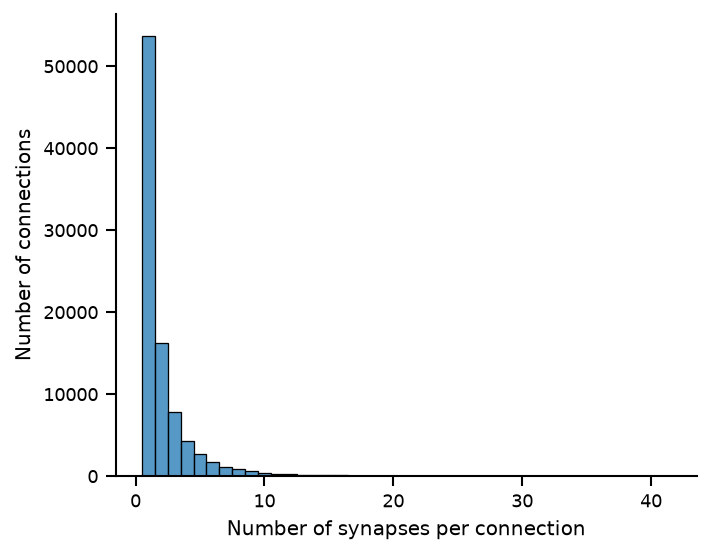

In [19]:
# generate adjacency matrix with a count of synapses
syn_mat = make_adjacency(syn_df, proof_root_ids, aggfunc=lambda x: np.sum(x > 0))

# Histogram on linear-x
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
edge_weights = syn_mat[row_indices, column_indices]
sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Number of synapses per connection", ylabel="Number of connections")

Next we plot the **number of synapses per connection**, or the `count`. We limit the colorbar to a maximum of 5, but the actual maximum number is much higher.

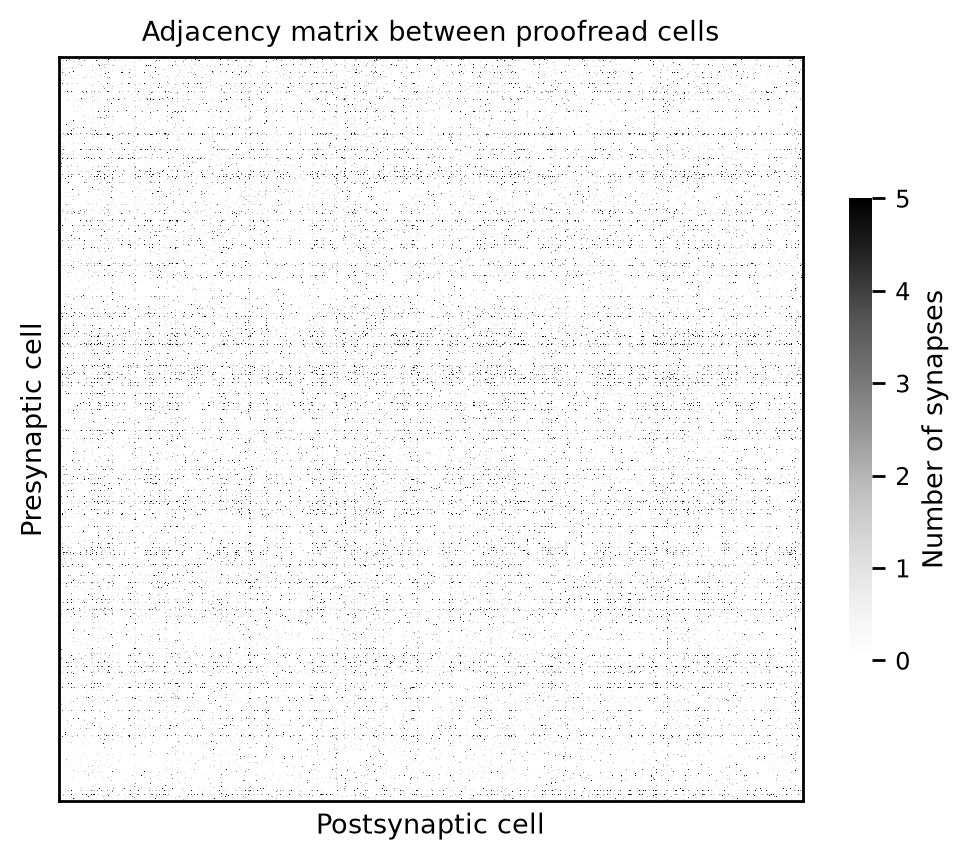

In [20]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
sns.heatmap(
    syn_mat,
    cbar=True,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    vmax=5,  # clip the color scale to 5 to see more edges
    ax=ax,
    cbar_kws={"label": "Number of synapses", "shrink": 0.5},
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell",
    ylabel="Presynaptic cell",
    title="Adjacency matrix between proofread cells",
)

## Cell type tables

Identifying the putative 'cell type' from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated 'feature classifiers' over time.

Two of the most predictive features for broad cell type are:

* **Soma location** in units of depth from pial surface. This captures cortical layer diversity.
* **Soma size** in units of volume. This is a strong proxy of many types of cell morphological diversity.


### Using the automated cell types

Many of these automated cell type definitions were established and refined for the [MICrONS Dataset](https://www.microns-explorer.org/), including:

* Perisomatic cell features ([Elabbady et al.](https://www.nature.com/articles/s41586-024-07765-7))
* Morphology and connectivity features ([Schneider-Mizell et al.](https://www.nature.com/articles/s41586-024-07780-8))

The process of applying these labels to the V1DD dataset is ongoing, but we will use cell typing from the `cell_type_multifeature_v1` table, which labels cell types using soma, nucleus, dendrite, and spine features.

Excitatory neurons are labeled by projection category (IT, ET, NP, CT, and SP for subplate).

Inhibitory neurons follow labels based on targeting such as ITC (inhibitory targeting), STC (sparsely targeting), PTC (perisomatic targeting), and DTC (dendrite targeting), but might align more with molecular class than exact targeting for a given neuron, particularly among ITC/VIP cells.


**QC Note: In Module 1 we queried this information from CAVE. In Module 2, this information is already aggregated in the CCM**. Both access patterns retrieve the same source of data, but the CCM data is limited to already 'good' cells (`n_soma==1`), those that have an interpretable dendrite. 

In [21]:
cell_df = (
    proofread_dendrites
    .select(
        pl.col("dataitem_id").cast(pl.UInt64).alias("pt_root_id"),
        pl.col("soma_voxel_x").alias("pt_position_x"),
        pl.col("soma_voxel_y").alias("pt_position_y"),
        pl.col("soma_voxel_z").alias("pt_position_z"),
        pl.col("soma_transformed_x").alias("pt_position_trform_x"),  # already um
        pl.col("soma_transformed_y").alias("pt_position_trform_y"),  # already um
        pl.col("soma_transformed_z").alias("pt_position_trform_z"),  # already um
        pl.col("soma_volume").alias("volume"),
        pl.col("v1dd_cell_types_level_1").alias("cell_type_coarse"),
        pl.col("v1dd_cell_types_level_2").alias("cell_type"),
    )
    .to_pandas()
)

cell_df.head()

,pt_root_id,pt_position_x,pt_position_y,pt_position_z,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,volume,cell_type_coarse,cell_type
0,864691132496108732,1655130.0,605358.0,776205.0,747210.937500,405236.90625,483669.812500,153.827026,None,None
1,864691132511800666,1227399.0,659134.0,270000.0,337011.062500,321753.62500,-17433.791016,257.700134,None,None
2,864691132525163794,1546956.0,533345.0,771210.0,654334.875000,333298.25000,499503.218750,258.204437,None,None
3,864691132533275738,641054.0,609626.0,372420.0,-246859.484375,304183.06250,93715.273438,226.991959,E,L4-IT
4,864691132533347418,805488.0,633759.0,299205.0,-82770.437500,307048.93750,16897.523438,217.654556,E,L4-IT


In [22]:
# Add a column that is soma depth in consistent units
cell_df['depth_um'] = cell_df['pt_position_trform_y'] # already um


## Sorting the synapse matrix with cell types

Let's combine the synaptic connectivity with the cell type information. Below we provide logic for sorting a connectivity matrix using a list of labels.

In [23]:
# Filter the proofread ids for those with a known cell type
proof_root_ids = np.intersect1d(proof_root_ids, cell_df["pt_root_id"].values)

# Filter the cell type table for those with a proofread root id
proof_cell_df = cell_df.set_index("pt_root_id").loc[proof_root_ids]
proof_cell_df = proof_cell_df.query("cell_type.notna()")

# NOTE: the adjacency matrix will be sorted according to this dataframe's index, so
# we'll sort it by soma depth
proof_cell_df = proof_cell_df.sort_values("pt_position_trform_y")

# Make adjacency, now including soma depth and cell type
syn_mat = make_adjacency(syn_df, proof_cell_df, aggfunc="sum")
syn_mat

array([[  0,   0, 274, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(1124, 1124))

**Note:** There are slightly fewer cells in this adjacency matrix because we are filtering for cells that have complete information in the cell table above.

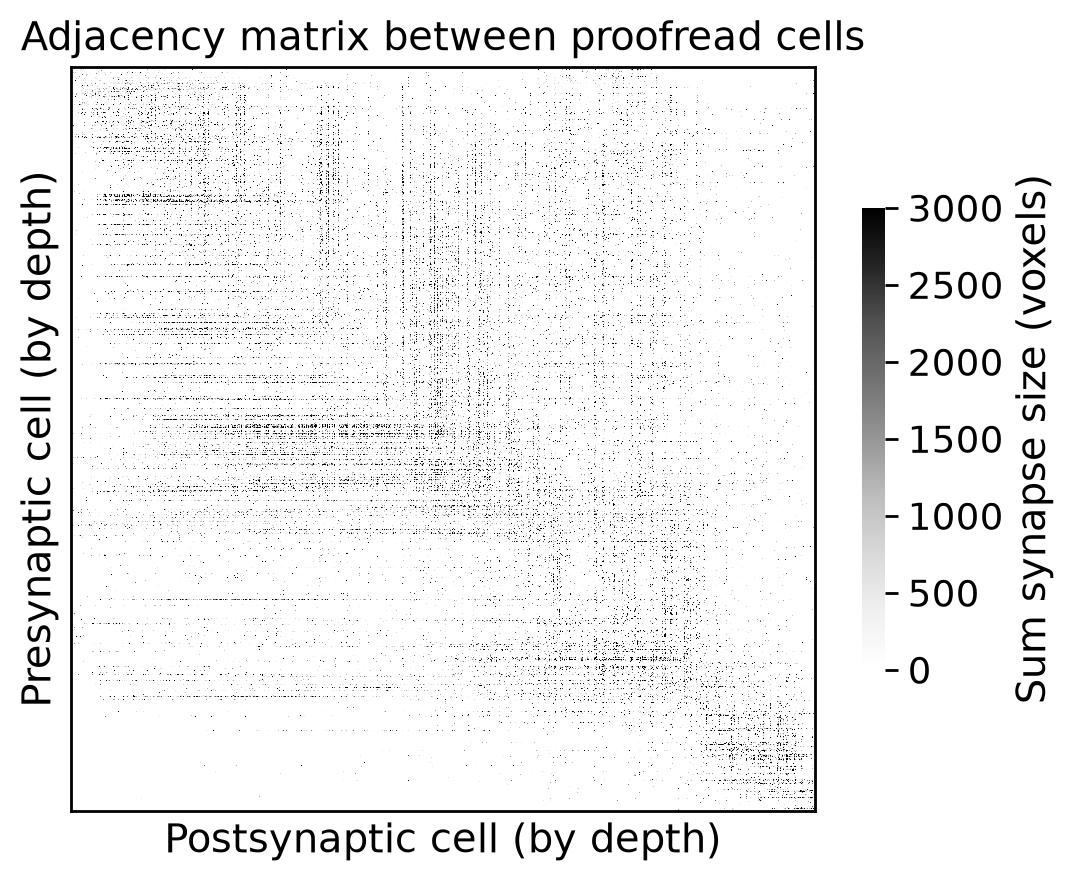

In [24]:
sns.set_context("paper", font_scale=1.5)
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
sns.heatmap(
    syn_mat,
    cbar=True,
    cmap="Greys",
    xticklabels=False,
    yticklabels=False,
    square=True,
    vmax=3000,
    ax=ax,
    cbar_kws={"label": r"Sum synapse size (voxels)", "shrink": 0.5},
)
ax.spines[["left", "right", "top", "bottom"]].set_visible(True)
_ = ax.set(
    xlabel="Postsynaptic cell (by depth)",
    ylabel="Presynaptic cell (by depth)",
    title="Adjacency matrix between proofread cells",
)

#### Task 4: Interpret connectivity by depth

There is a large amount of structure in the connectivity just based on soma depth. However, some rows are very narrow in their connectivity while others are very wide.

#### Discussion

What are some explanations for why the connectivity plot has a strong diagonal component? In contrast, what does the wide connectivity in a row or column mean?

### Add cell type logic to the adjacency plot

What about the effect of cell types on the connectivity matrix? We can add colors and subplots by cell type to make this matrix more tractable. We have packaged away the logic for this in `adjacencyplot`, which can group and sort the adjacency matrix by metadata in the cell table.

The logic here is similar to the plotting package `seaborn`, where different labels within the data can be leveraged to control different elements.

(<Axes: >, <utils.AxisGrid at 0x7fd441cdb2c0>)

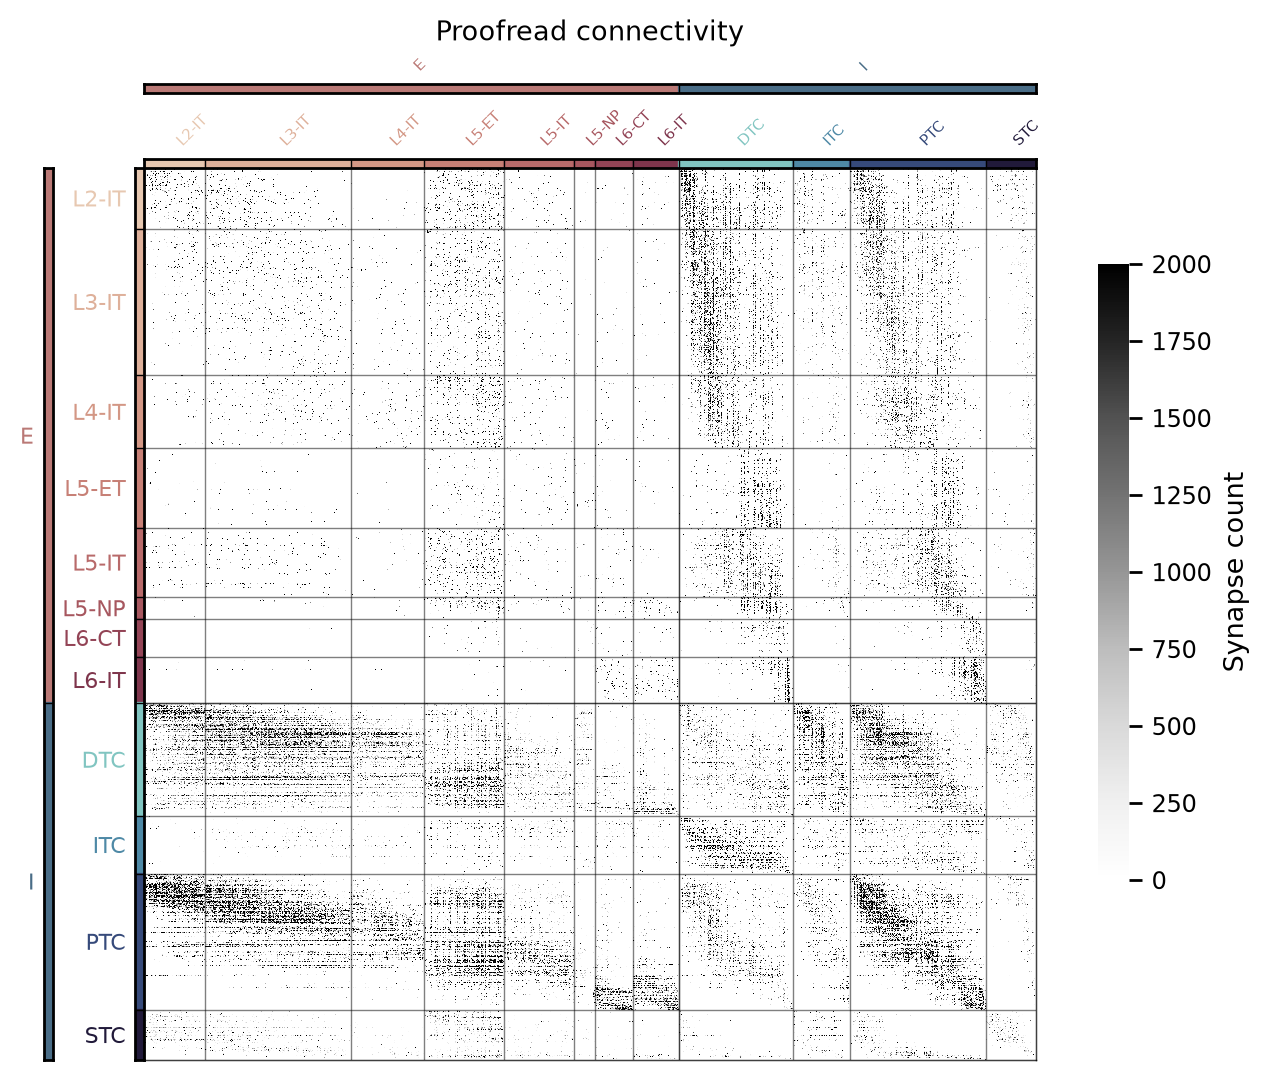

In [25]:
from utils import adjacencyplot, cell_type_palette

sns.set_context('paper', font_scale=1.0)

fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

# render the adjacency plot
adjacencyplot(
    syn_mat,  # data values for the points
    nodes=proof_cell_df,  # data to organize the x and y axis
    groupby=["cell_type_coarse", "cell_type"],  # categorical variables to organize by
    sortby="pt_position_y",  # sort within groups by variable
    node_palette=cell_type_palette,
    title="Proofread connectivity",
    edge_palette="Greys",
    hue_norm=(0, 2000),  # normalize the color scale for the edges
    ax=ax,
    label_fontsize="xx-small",
    title_fontsize="medium",
    arc_labels=False
)

#### Task 5: Identify a cell in the connectivity matrix

Now we have restructured the connectivity based on cell type. Find one of your example cells from this morning and identify its row or column. Hint: query `proof_cell_df` by your `root_id`.

#### Discussion

Describe the connectivity for your cell by who it targets and who it receives inputs from.

Then, for each row, describe that cell type by its major targets. Do you think there are more subgroups within the cell types?

In [26]:
# Query the cell type of your root_id:
root_id = 864691132534315610 # Known example neuron. You may iterate 

proof_cell_df.query(f"pt_root_id=={root_id}")[["cell_type_coarse", "cell_type"]]

,cell_type_coarse,cell_type
pt_root_id,,
864691132534315610,E,L4-IT


<hr style="height: 4px; background: #000; border: none;">

<h2 align="center">Coffee break</h2>

<p align="center">After the break we pick up a different question &mdash; whether the <i>connectivity</i> of neurons tells us anything about how <i>correlated</i> their <i>function is</i>.</p>

<hr style="height: 4px; background: #000; border: none;">

# Connectomics Module 2b: Connectivity principles and structure–function

What predicts whether any two neurons are connected, when we look past cell type to
**where the neurons are** and **what they do**?

We test two candidate rules, and then ask whether they are redundant:

1. **Space.** Are nearby neurons more likely to be connected?
2. **Function.** Are co-active neurons more likely to be connected?
3. **A stronger null model.** Distance predicts connectivity, and nearby neurons tend to
   be co-active. So is the structure–function correlation in (2) anything more than a
   restatement of (1)?

Throughout we work with **L3-IT** pyramidal cells, the excitatory population with the
most proofread axons in V1DD. Fixing the cell type is what lets us isolate the effects of
space and activity.

> **Solutions notebook.** Task cells are filled in. The student version, with those cells
> blank, is `workshops/Module_2.ipynb`. The two are otherwise identical — if you edit one,
> edit the other.

## Loading the data

Two sources carry the whole module:

| source | holds | one row per | loaded in |
| --- | --- | --- | --- |
| `v1dd_1196_ccm` | proofreading, soma positions, cell types, synapses | cell / synapse | below |
| `cell_cell_correlations_by_stimulus_coregistered.feather` | activity correlations | neuron pair | Part 2 |

The first is the **Common Connectivity** release that Module 2 also reads — one store
holding the EM side of the dataset, queried through `DatasetReader` rather than by opening
files by name. The second comes from the two-photon side and we pick it up in Part 2.

No CAVEclient calls: unlike Module 1, everything below is already materialised.

### The Common Connectivity store

A Common Connectivity release organises cells into named **datasets** (here, cohorts
defined by what has been proofread), each carrying **feature sets** (measurements, such as
soma position) and **cluster sets** (categorical labels, such as cell type). Asking the
reader what it contains is the first thing to do with an unfamiliar release.

In [3]:
reader = DatasetReader(ccm_dir)

reader.display_dataset_names()

id,name,project_id,modality
str,str,str,str
"""v1dd_1196_em""","""V1DD release 1196 — EM somas""","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_axons""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_dendrites""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""


Reading a dataset returns one wide row per cell, with every related feature and label
joined on. Two cohorts matter here, and the distinction between them is the single most
important methodological point in this module:

- **`proofread_dendrites`** — cells whose dendrites can be trusted. Dendrites are largely
  complete straight out of automated segmentation, so this is most reconstructed neurons.
  A synapse *onto* one of these cells will have been found if it exists.
- **`proofread_axons`** — cells whose axons have been manually extended and cleaned. This
  is expensive human work, so it is a small, deliberately chosen subset. Only for these
  cells does "no synapse found" mean "no synapse".

In [4]:
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()
dendrite_proof_root_ids = proofread_dendrites["dataitem_id"].cast(pl.UInt64).to_numpy()

print(f"{len(axon_proof_root_ids):>6,} cells with proofread axons")
print(f"{len(dendrite_proof_root_ids):>6,} cells with acceptable dendrites")
print(
    f"{np.isin(axon_proof_root_ids, dendrite_proof_root_ids).sum():>6,} cells with both"
)

proofread_dendrites.head(3)

 1,164 cells with proofread axons
63,986 cells with acceptable dendrites
 1,148 cells with both


dataitem_id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,soma_voxel_x,soma_voxel_y,soma_voxel_z,soma_transformed_x,soma_transformed_y,soma_transformed_z,soma_volume,v1dd_cell_types_level_0,v1dd_cell_types_level_1,v1dd_cell_types_level_2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,str,str,str
"""864691132496108732""",153.714823,262.44489,1.891226,87.028684,0.331607,0.52135,294.840211,292.666366,1.613731,1.366147,0.068337,1.65513e6,605358.0,776205.0,747.656006,423.467957,484.288116,153.827026,null,null,null
"""864691132511800666""",257.461754,283.770235,1.44991,42.661132,0.150337,0.968305,265.88904,281.628224,0.120611,1.408397,0.014203,1.227399e6,659134.0,270000.0,338.375732,340.317505,-18.48254,257.700134,null,null,null
"""864691132525163794""",258.152734,266.504962,1.359263,38.271973,0.143607,0.427513,603.847392,767.669205,0.686228,2.221972,0.087277,1.546956e6,533345.0,771210.0,655.235413,351.830109,498.754974,258.204437,null,null,null


### Cells: position and type

We pull the columns this module needs out of the dendrite cohort into a pandas frame.

Two coordinate systems are on offer, and picking the wrong one quietly corrupts every
distance you compute:

- `soma_voxel_*` — the raw EM coordinates. Use these to look a neuron up in Neuroglancer.
- `soma_transformed_*` — the same somas after rotating the pial surface flat and anchoring
  it to y = 0, in **µm**. The volume was not imaged perfectly upright, so only in these
  coordinates does "y" mean cortical depth and "x, z" mean tangential position. Use these
  for anything geometric.

`v1dd_cell_types` is a three-level hierarchy: everything is a `neuron`, splitting into
excitatory/inhibitory (`E`/`I`), splitting into the types Module 2 sorted the synapse
matrix by — excitatory by layer and projection class (`L3-IT`, `L5-ET`, `L6-CT`, ...),
inhibitory by what they target (`PTC`, `DTC`, `ITC`, `STC`).

In [5]:
cell_df = proofread_dendrites.select(
    pl.col("dataitem_id").cast(pl.UInt64).alias("pt_root_id"),
    # transformed coordinates, already in µm
    pl.col("soma_transformed_x").alias("pt_position_trform_x"),
    pl.col("soma_transformed_y").alias("pt_position_trform_y"),
    pl.col("soma_transformed_z").alias("pt_position_trform_z"),
    pl.col("soma_volume").alias("volume"),
    pl.col("v1dd_cell_types_level_1").alias("cell_type_coarse"),
    pl.col("v1dd_cell_types_level_2").alias("cell_type"),
).to_pandas()

cell_df.head(3)

,pt_root_id,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,volume,cell_type_coarse,cell_type
0,864691132496108732,747.656006,423.467957,484.288116,153.827026,None,None
1,864691132511800666,338.375732,340.317505,-18.482540,257.700134,None,None
2,864691132525163794,655.235413,351.830109,498.754974,258.204437,None,None


In [6]:
cell_df["cell_type"].value_counts()

cell_type
L6-CT    11260
L4-IT     7955
L3-IT     6361
L6-IT     6044
L5-IT     5090
L2-IT     3073
PTC       2951
L5-ET     2013
DTC       1933
ITC       1090
STC        723
L5-NP      699
Name: count, dtype: int64

### Synapses

`read_synapse_table` returns the long list of synapses — one row per synapse, naming the
cell on each side. `features=True` joins the per-synapse measurements (position, size)
from the named feature matrix. We rename the two cell columns to the `pre_pt_root_id` /
`post_pt_root_id` convention the rest of the workshop uses.

In [7]:
synapse_data = read_synapse_table(
    project_id,
    dataset_id=synapse_dataset_id,
    features=True,
    feature_matrix_id=synapse_feature_matrix_id,
    output_root=ccm_dir,
)

syn_df = (
    synapse_data.with_columns(
        pl.col("id").cast(pl.UInt64),
        pl.col("presynaptic_cell").cast(pl.UInt64),
        pl.col("postsynaptic_cell").cast(pl.UInt64),
    )
    .rename(
        {
            "presynaptic_cell": "pre_pt_root_id",
            "postsynaptic_cell": "post_pt_root_id",
        }
    )
    .select(["id", "pre_pt_root_id", "post_pt_root_id", "size"])
    .to_pandas()
)

print(f"{len(syn_df):,} synapses")
syn_df.head(3)

8,204,497 synapses


,id,pre_pt_root_id,post_pt_root_id,size
0,354386968,864691132536286810,864691132734919083,240
1,378070488,864691132572190492,864691132606767301,3056
2,499493001,864691132573738810,864691132747578447,1346


## Part 1: Connection probability vs. distance

**Why expect distance to matter at all?** A synapse can only form where an axon and a
dendrite physically touch. Both arbors are finite — a cortical pyramidal cell's dendrites
span a couple of hundred µm, its local axon somewhat more — so two neurons far apart in
the tangential plane simply have less opportunity to meet. Wiring also costs the animal
volume, metabolism and conduction delay, all of which push toward local connections. The
strong version of this idea, that connection probability follows arbor overlap and nothing
else, is known as **Peters' rule**, and it is the natural first hypothesis to test.

Whether it is *sufficient* is exactly what Part 3 comes back to.

We compare the distance distribution of *all* L3-IT pairs against the distance
distribution of *connected* L3-IT pairs.

In [8]:
sub_cell_df = cell_df[cell_df["cell_type"] == "L3-IT"]

print(f"{len(sub_cell_df)} L3-IT cells")

6361 L3-IT cells


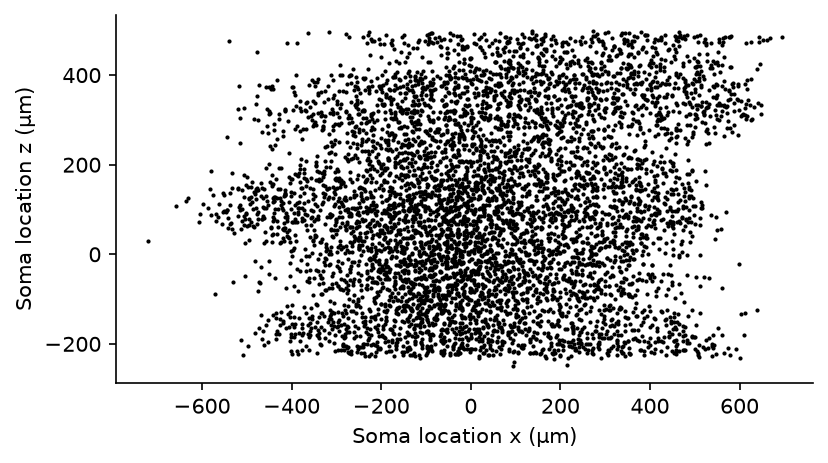

In [9]:
# Figure 1: Soma positions of all L3-IT cells, viewed from the top (tangential plane)

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ax.scatter(
    data=sub_cell_df, x="pt_position_trform_x", y="pt_position_trform_z", c="k", s=1
)

ax.set(xlabel="Soma location x (µm)", ylabel="Soma location z (µm)", aspect="equal")
sns.despine()
plt.show()

**Task:** Are the proofread neurons evenly distributed through the volume? Filter
`sub_cell_df` to cells with proofread axons and plot them on top of all L3-IT somas.

*Hint:* keep ids that are also in `axon_proof_root_ids`.

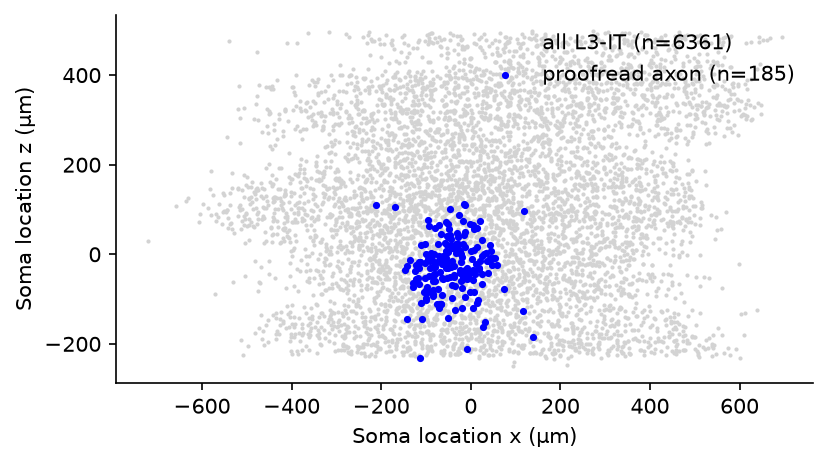

In [10]:
# Figure 1b: Cells with proofread axons are a sparse, uneven subset

proof_cell_df = sub_cell_df[np.isin(sub_cell_df["pt_root_id"], axon_proof_root_ids)]

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ax.scatter(
    data=sub_cell_df,
    x="pt_position_trform_x",
    y="pt_position_trform_z",
    c="lightgrey",
    s=1,
    label=f"all L3-IT (n={len(sub_cell_df)})",
)
ax.scatter(
    data=proof_cell_df,
    x="pt_position_trform_x",
    y="pt_position_trform_z",
    c="b",
    s=6,
    label=f"proofread axon (n={len(proof_cell_df)})",
)

ax.legend(frameon=False, loc="upper right")
ax.set(xlabel="Soma location x (µm)", ylabel="Soma location z (µm)", aspect="equal")
sns.despine()
plt.show()

# Proofreading was targeted, not random: effort concentrates where the columns were
# imaged, so the testable pairs are biased toward short separations.

### Lateral distance between somas

We use *lateral* distance — the distance in the tangential (x, z) plane, ignoring cortical
depth. Two reasons, one biological and one statistical. Biologically, depth *is* layer, and
layer is cell type: a neuron 300 µm below another is in a different layer and belongs to a
different population with different partners, which is a different effect from being 300 µm
to the side. Statistically, we already fixed cell type by taking L3-IT alone, so the
remaining depth spread is thin and mostly reflects where in L3 a soma sits. Collapsing it
gives us the quantity we actually mean by "nearby in the cortical sheet".

For one pair it is just a vector norm:

In [11]:
pos_cols = ["pt_position_trform_x", "pt_position_trform_z"]

difference = sub_cell_df.iloc[0][pos_cols] - sub_cell_df.iloc[1][pos_cols]
np.linalg.norm(difference)

np.float32(393.98657)

And for all pairs at once with `scipy.spatial.distance.cdist`:

In [12]:
def calculate_lateral_distances(pre_cell_df, post_cell_df=None):
    """Calculates the lateral distances in µm between all neurons."""
    if post_cell_df is None:
        post_cell_df = pre_cell_df

    pre_lateral_locations = np.array(
        pre_cell_df[["pt_position_trform_x", "pt_position_trform_z"]]
    )
    post_lateral_locations = np.array(
        post_cell_df[["pt_position_trform_x", "pt_position_trform_z"]]
    )
    lateral_distances = spatial.distance.cdist(
        pre_lateral_locations, post_lateral_locations
    )

    id_pairs = list(
        itertools.product(pre_cell_df["pt_root_id"], post_cell_df["pt_root_id"])
    )

    lateral_distance_df = pd.DataFrame(
        id_pairs, columns=["pre_pt_root_id", "post_pt_root_id"]
    )
    lateral_distance_df["distance"] = lateral_distances.flatten()

    # drop self-pairs
    lateral_distance_df = lateral_distance_df[
        lateral_distance_df["pre_pt_root_id"] != lateral_distance_df["post_pt_root_id"]
    ]
    return lateral_distance_df

In [13]:
# This will take a minute to complete
lateral_distance_df = calculate_lateral_distances(sub_cell_df)

lateral_distance_df.head(3)

,pre_pt_root_id,post_pt_root_id,distance
1,864691132533643098,864691132533648218,393.986590
2,864691132533643098,864691132533665626,530.098968
3,864691132533643098,864691132533673818,377.014864


### Lateral distance between all pairs and proofread pairs

The distribution above covers *all* L3-IT pairs. But we are about to count how often pairs
are connected, and for that a pair is only **testable** if the presynaptic cell has a
proofread axon and the postsynaptic cell an acceptable dendrite.

This is worth pausing on, because it is the trap that catches most people using a
connectome for the first time. If an axon was never traced to its end, the synapses on its
missing branches are missing from the table too. Counting those pairs as "not connected"
would mix two entirely different statements — *we looked and there is no synapse* and *we
did not finish looking* — and the second is far more common. Every comparison in this
module is therefore against proofread pairs only, and the numbers are smaller for it.

Comparing the two distributions shows what that restriction costs us.

In [14]:
# Gathering proofread L3-IT IDs
pre_root_ids = sub_cell_df["pt_root_id"][
    np.isin(sub_cell_df["pt_root_id"], axon_proof_root_ids)
]
post_root_ids = sub_cell_df["pt_root_id"][
    np.isin(sub_cell_df["pt_root_id"], dendrite_proof_root_ids)
]

lateral_distance_proofread_df = lateral_distance_df[
    np.isin(lateral_distance_df["pre_pt_root_id"], pre_root_ids)
    & np.isin(lateral_distance_df["post_pt_root_id"], post_root_ids)
]

print(f"{len(lateral_distance_df):>9,} L3-IT pairs")
print(f"{len(lateral_distance_proofread_df):>9,} testable (proofread) L3-IT pairs")

40,455,960 L3-IT pairs
1,246,560 testable (proofread) L3-IT pairs


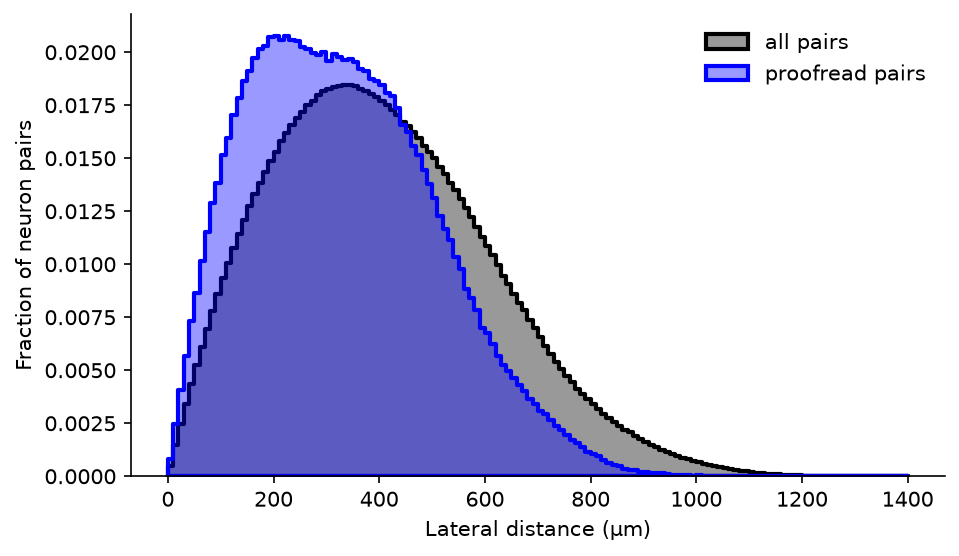

In [15]:
# Figure 2: Distance distribution, all pairs vs. testable pairs
# `stat="proportion"` is what makes the two populations comparable despite different N

bins = np.linspace(0, 1400, 141)

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

for df, color, label in [
    (lateral_distance_df, "k", "all pairs"),
    (lateral_distance_proofread_df, "b", "proofread pairs"),
]:
    sns.histplot(
        df,
        x="distance",
        stat="proportion",
        bins=bins,
        element="step",
        fill=True,
        alpha=0.4,
        lw=2,
        color=color,
        label=label,
        ax=ax,
    )

ax.legend(frameon=False)
ax.set(xlabel="Lateral distance (µm)", ylabel="Fraction of neuron pairs")
sns.despine()
plt.show()

### Interlude: is a difference between two distributions real?

We just eyeballed two histograms and said one is shifted. Every comparison in this module
is of that form, so it is worth setting up the machinery once.

**The definition.** A **null hypothesis** $H_0$ is a specific claim that nothing
interesting is going on — here, *the two samples are drawn from the same distribution*.
Choose a **test statistic** $T$ whose large values would be surprising under $H_0$, observe
its value $t_{\text{obs}}$, and report

$$p \;=\; \Pr\!\left(T \ge t_{\text{obs}} \;\middle|\; H_0\right).$$

That is: *if the null were true, how often would we see a statistic at least this extreme?*
A small $p$ means the data would be unusual under $H_0$, so $H_0$ is a poor explanation.

Two things $p$ is **not**. It is not the probability that $H_0$ is true — that quantity is
not even defined in this framework, which assigns no probability to hypotheses. And it says
nothing about how *large* the effect is: with enough data, a difference too small to care
about still gets a tiny $p$. Effect size is a separate question, and we report one alongside
every $p$ below.

*(Casella & Berger, [Statistical Inference](https://www.cengage.com/c/statistical-inference-2e-casella/), 2nd ed., §8.3.4 gives the formal definition;
Wasserman, [All of Statistics](https://link.springer.com/book/10.1007/978-0-387-21736-9), §10.2 is a compact treatment.)*

**The test.** Our distributions are skewed and the two groups differ wildly in size, so we
use the **Mann–Whitney U test** rather than anything assuming normality. It ranks all the
values together and counts how often a draw from one group beats a draw from the other:

$$U \;=\; \#\{(i,j) : x_i > y_j\} \;+\; \tfrac{1}{2}\,\#\{(i,j) : x_i = y_j\},
\qquad \mathrm{AUC} \;=\; \frac{U}{n_x n_y}.$$

$H_0$ is that a random $x$ is equally likely to fall above or below a random $y$, so
$\mathrm{AUC} = 0.5$. That normalised $U$ is the effect size we want, and it has a plain
reading: **the probability that a random member of the first group exceeds a random member
of the second.** 0.5 is no difference, 1.0 is perfect separation.
*(Mann & Whitney, [Ann. Math. Statist. 18:50–60, 1947](https://doi.org/10.1214/aoms/1177730491).)*

In [16]:
def compare_distributions(sample_a, sample_b, name_a="a", name_b="b"):
    """Mann-Whitney U test between two samples, with its effect size.

    Returns (p, auc), where auc is the probability that a random draw from
    `sample_a` exceeds a random draw from `sample_b`. 0.5 means no difference.
    """
    sample_a = np.asarray(sample_a)
    sample_b = np.asarray(sample_b)
    u, p = stats.mannwhitneyu(sample_a, sample_b, alternative="two-sided")
    auc = u / (len(sample_a) * len(sample_b))

    # scipy's normal approximation underflows to exactly 0.0 far enough into the tail,
    # and a p-value of 0 is not a real quantity. Report the precision limit instead.
    p_text = f"{p:.3g}" if p > 0 else "<1e-300"

    print(f"{name_a} (n={len(sample_a):,})  vs  {name_b} (n={len(sample_b):,})")
    print(
        f"  median      {np.median(sample_a):>10.4g}  vs {np.median(sample_b):>10.4g}"
    )
    print(f"  p           {p_text:>10}")
    print(f"  AUC         {auc:>10.3f}   (0.5 = indistinguishable)")
    print(f"     a random '{name_a}' exceeds a random '{name_b}' {auc:.1%} of the time")
    return p, auc

Applied to Figure 2 — and note we compare the testable pairs against the ones we
*cannot* test, rather than against all pairs, since the testable set is part of "all" and a
nested comparison would dilute exactly the difference we are asking about.

In [17]:
untestable_distances = lateral_distance_df.loc[
    ~lateral_distance_df.index.isin(lateral_distance_proofread_df.index), "distance"
]

p, auc = compare_distributions(
    lateral_distance_proofread_df["distance"],
    untestable_distances,
    "testable pairs",
    "untestable pairs",
)

testable pairs (n=1,246,560)  vs  untestable pairs (n=39,209,400)
  median           317.5  vs      390.3
  p              <1e-300
  AUC              0.395   (0.5 = indistinguishable)
     a random 'testable pairs' exceeds a random 'untestable pairs' 39.5% of the time


So proofreading really did bias which pairs we can test toward shorter separations. That is
a fact about the dataset, not about the brain — and it is the reason every comparison from
here on stays inside the testable set.

Two details worth noticing in that output. The $p$-value **underflows**: with 39 million
comparisons the statistic is so far into the tail that the normal approximation returns
exactly `0.0` in double precision. Zero is not a probability any finite computation can
establish, so the helper reports `<1e-300`. And with $n$ this large, $p$ has stopped being
informative at all — *any* difference, however trivial, would be "significant". The AUC is
the number that still carries meaning.

### Lateral distance between connected pairs

Now the connected pairs. We filter the synapse table down to the testable L3-IT pairs,
then collapse multi-synaptic connections: a pair joined by four synapses is still *one*
connection, with a summed synapse size.

In [18]:
analysis_syn_df = filter_synapse_table(syn_df, pre_root_ids, post_root_ids).reset_index(
    drop=True
)

conn_df = (
    analysis_syn_df.groupby(["pre_pt_root_id", "post_pt_root_id"])["size"]
    .sum()
    .reset_index()
)

print(f"{len(analysis_syn_df):,} synapses -> {len(conn_df):,} unique connections")
conn_df.head(3)

10,316 synapses -> 9,655 unique connections


,pre_pt_root_id,post_pt_root_id,size
0,864691132548503618,864691132543938961,2388
1,864691132548503618,864691132569612060,2471
2,864691132548503618,864691132574630714,3758


**Task:** For each connection we want the distance between the two neurons. Write the
`pd.merge` that combines `conn_df` and `lateral_distance_df` into `conn_dist_df`. The
connectivity table is much smaller than the distance table, so the merge doubles as a
filter: it keeps only the pairs that are connected.

*Hint:* `pd.merge` can merge on several columns at once.

In [19]:
conn_dist_df = pd.merge(
    conn_df, lateral_distance_df, on=["pre_pt_root_id", "post_pt_root_id"]
)

conn_dist_df.head(3)

,pre_pt_root_id,post_pt_root_id,size,distance
0,864691132548503618,864691132543938961,2388,26.568672
1,864691132548503618,864691132569612060,2471,358.268604
2,864691132548503618,864691132574630714,3758,59.130357


In [20]:
conn_dist_df.shape, conn_df.shape, lateral_distance_df.shape

((9678, 4), (9655, 3), (40455960, 3))

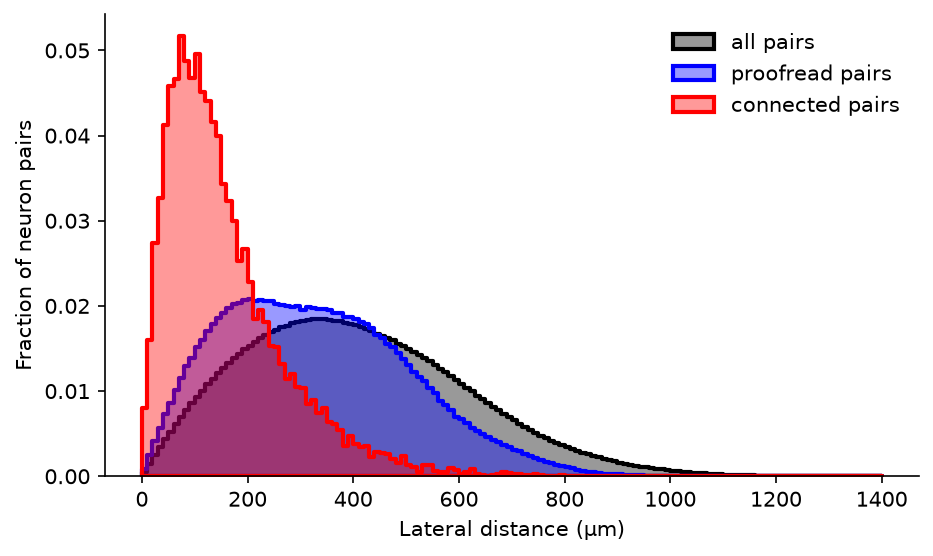

In [21]:
# Figure 3: Connected pairs are shifted toward short distances

bins = np.linspace(0, 1400, 141)

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

for df, color, label in [
    (lateral_distance_df, "k", "all pairs"),
    (lateral_distance_proofread_df, "b", "proofread pairs"),
    (conn_dist_df, "r", "connected pairs"),
]:
    sns.histplot(
        df,
        x="distance",
        stat="proportion",
        bins=bins,
        element="step",
        fill=True,
        alpha=0.4,
        lw=2,
        color=color,
        label=label,
        ax=ax,
    )

ax.legend(frameon=False)
ax.set(xlabel="Lateral distance (µm)", ylabel="Fraction of neuron pairs")
sns.despine()
plt.show()

Now the comparison that carries Part 1's claim: among pairs we can test, are the connected
ones closer together?

In [22]:
connected_keys = set(
    map(tuple, conn_dist_df[["pre_pt_root_id", "post_pt_root_id"]].values)
)
is_connected = [
    key in connected_keys
    for key in map(
        tuple,
        lateral_distance_proofread_df[["pre_pt_root_id", "post_pt_root_id"]].values,
    )
]
is_connected = np.array(is_connected)

p, auc = compare_distributions(
    lateral_distance_proofread_df["distance"][is_connected],
    lateral_distance_proofread_df["distance"][~is_connected],
    "connected",
    "not connected",
)

connected (n=9,655)  vs  not connected (n=1,236,905)
  median           129.2  vs        319
  p              <1e-300
  AUC              0.190   (0.5 = indistinguishable)
     a random 'connected' exceeds a random 'not connected' 19.0% of the time


An AUC well below 0.5 means connected pairs sit at *shorter* distances: a connected pair is
farther apart than an unconnected one only about 19% of the time, so it is the closer of the
two roughly four times in five. Compare the medians — 129 µm against 319 µm.

That is a large effect, and worth holding on to as a reference point. Part 2 runs the same
test on activity correlations and gets a $p$-value just as convincing with an effect size
nowhere near this one.

### From distributions to a connection probability

The ratio of the red to the blue histogram, bin by bin, answers a more direct question:
**how likely is it that two neurons are connected, given their lateral distance?**

In [23]:
bins = np.linspace(0, 500, 101)  # 5 µm bins

proofread_pair_counts = np.histogram(lateral_distance_proofread_df["distance"], bins)[0]
connected_pair_counts = np.histogram(conn_dist_df["distance"], bins)[0]

connection_probability = connected_pair_counts / proofread_pair_counts

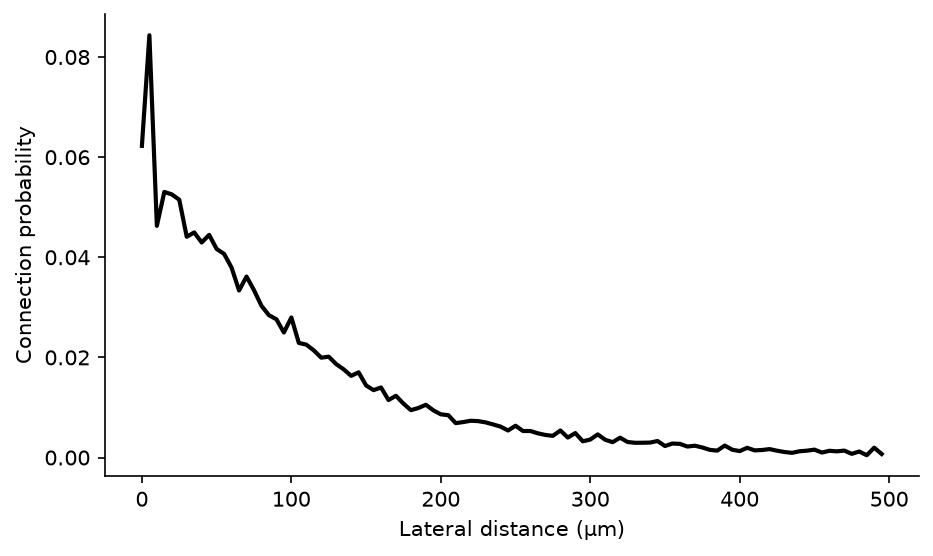

In [24]:
# Figure 4: Connection probability falls off with lateral distance

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

sns.lineplot(x=bins[:-1], y=connection_probability, lw=2, color="k", ax=ax)

ax.set(xlabel="Lateral distance (µm)", ylabel="Connection probability")
sns.despine()
plt.show()

To build intuition for what these numbers look like in the volume, here are connected
L3-IT pairs at four separations:

- 10 µm: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5054147278667776>
- 50 µm: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5895810897149952>
- 100 µm: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5101346838544384>
- 500 µm: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6458760850571264>

**Task:** Find the synapse between the 500 µm pair.

## Part 2: Structure vs. function

**Why expect activity to predict connectivity?** If a synapse strengthens when the two
cells it joins tend to fire together — Hebb's rule, and the best-supported mechanism of
cortical plasticity — then over the animal's lifetime connections should accumulate between
cells that respond to similar things. Independently of learning, two neurons that share
input from the same thalamic or cortical source are both more likely to be co-active *and*
more likely to be near each other and connected. Either way the prediction is the same:
connected pairs should be more correlated than unconnected ones. This "like-to-like"
connectivity is one of the central claims about cortical circuits, and it needs exactly
this kind of dataset to test, because it requires the wiring and the activity of the
*same* neurons.

V1DD is a **structure–function** dataset: many of the reconstructed neurons were also
recorded with two-photon calcium imaging before the tissue was sectioned. For background on
the physiology side, see the
[V1 Deep Dive Overview](https://allenswdb.github.io/physiology/ophys/V1DD/V1DD-overview.html)
in the DataBook.

Two things make this work:

- **Activity correlations.** For each pair of simultaneously imaged cells, the correlation
  of their ΔF/F traces during each stimulus condition. This is precomputed, and the next
  section shows where it comes from and how to compute it differently.
- **Coregistration.** An ROI in the functional stack has to be matched to a cell body in
  the EM stack — two separate imaging modalities, different tissue geometry, matched by
  hand. It succeeds for a minority of cells, which is why N drops sharply here.

> This table has 8 identifier columns and **7** stimulus conditions — including
> `spontaneous`, a grey-screen baseline that is useful as a control but is not a visual
> stimulus.

In [25]:
corr_coreg_df = pd.read_feather(
    f"{functional_dir}/cell_cell_correlations_by_stimulus_coregistered.feather"
)

corr_coreg_df.head(3)

,column,volume,pre_plane,pre_roi,post_plane,post_roi,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,natural_images,natural_images_12,natural_movie,spontaneous,pre_pt_root_id,post_pt_root_id
0,2,5,2,4,2,9,0.038841,-0.033496,0.031585,0.067912,-0.002068,0.101562,0.065001,864691132578859796,864691132784139762
1,2,5,2,4,2,13,0.043010,-0.014050,-0.073923,-0.009737,0.096574,-0.056540,0.000869,864691132578859796,864691132802605719
2,2,5,2,4,2,16,0.434037,0.061785,0.435529,0.220942,0.025282,0.279407,0.215425,864691132578859796,864691132761554538


In [ ]:
# Everything that is not an identifier column is a stimulus condition
stimulus_conditions = corr_coreg_df.columns.drop(["pre_pt_root_id", "post_pt_root_id",
                                                  "column", "volume", 
                                                  "pre_plane", "pre_roi", 
                                                  "post_plane", "post_roi",])

stimulus_conditions

Index(['column', 'volume', 'pre_plane', 'pre_roi', 'post_plane', 'post_roi',
       'drifting_gratings_full', 'drifting_gratings_windowed',
       'locally_sparse_noise', 'natural_images', 'natural_images_12',
       'natural_movie', 'spontaneous'],
      dtype='object')

Seven conditions are seven separate measurements, and they need not agree. We fix **one**
for the rest of the module and leave the comparison to the exercises.

`natural_images` is the choice: naturalistic stimuli drive rich, differentiated population
activity, so what remains in the correlations is informative rather than a signature of the
whole population being driven in lockstep.

In [27]:
stim = "natural_images"

### Where these numbers come from, and how to change them

Each value is a **Pearson correlation between two ΔF/F traces**, computed over the frames
belonging to one stimulus condition. The pipeline that produces the table is
[Functional Data Cell-Cell Correlations.ipynb](../supplement/Functional%20Data%20Cell-Cell%20Correlations.ipynb):
it opens the V1DD two-photon NWB-Zarr sessions, puts every imaging plane on a common
timebase, labels each frame with the stimulus on screen, runs `np.corrcoef` over the frames
of each condition, and merges in coregistration to attach EM root ids.

Pearson r is a *choice*. It throws away each cell's baseline and gain, weights every frame
equally, and only sees linear relationships. "These two neurons do the same thing" could
just as reasonably mean *they prefer the same images* (correlate trial-averaged responses
instead — signal rather than noise correlation), or *they are active to the same degree*
(cosine similarity, which keeps the mean), or *they rise and fall together regardless of
amplitude* (rank correlation).

So `utils/functional_similarity.py` generalises that pipeline step: same long output
format, but the measure is an argument. Anything downstream of the table works unchanged.
See also Exercise 4.

In [28]:
from functional_similarity import (
    cosine_similarity,
    pairwise_similarity_table,
    pearson_correlation,
    spearman_correlation,
)

# A small synthetic check, so the difference between measures is visible without loading
# the NWB sessions: 4 cells driven by 2 shared signals, plus per-cell baseline offsets.
rng = np.random.default_rng(0)
n_frames = 600
shared = rng.normal(size=(2, n_frames))
demo_traces = np.stack(
    [shared[i // 2] + 0.3 * rng.normal(size=n_frames) for i in range(4)]
)
demo_traces += np.array([[0.0], [5.0], [0.0], [5.0]])  # different baselines

demo_mask = np.repeat([1, 2], n_frames // 2)
demo_names = {1: "condition_a", 2: "condition_b"}

pairwise_similarity_table(demo_traces, demo_mask, demo_names).head(3)

  condition_a                       300 frames
  condition_b                       300 frames


,pre_pt_root_id,post_pt_root_id,condition_a,condition_b
0,0,1,0.919231,0.909049
1,0,2,0.023962,0.031070
2,0,3,0.017173,0.011427


By construction cells **0 and 1** share one signal and cells **2 and 3** share another, so
the honest answer is that 0–1 and 2–3 are the similar pairs. Each measure is now asked to
recover that.

In [29]:
# `symmetric=False` gives each unordered pair once, so there are 6 rows to compare
demo_pairs = pairwise_similarity_table(
    demo_traces, demo_mask, demo_names, neuron_ids=[0, 1, 2, 3], symmetric=False
)

comparison = demo_pairs[["pre_pt_root_id", "post_pt_root_id"]].copy()
for name, metric in [
    ("pearson", pearson_correlation),
    ("cosine", cosine_similarity),
    ("spearman", spearman_correlation),
]:
    comparison[name] = pairwise_similarity_table(
        demo_traces,
        demo_mask,
        demo_names,
        metric=metric,
        neuron_ids=[0, 1, 2, 3],
        symmetric=False,
    )["condition_a"]

comparison["pair"] = (
    comparison["pre_pt_root_id"].astype(str)
    + "-"
    + comparison["post_pt_root_id"].astype(str)
)
comparison["shares a signal"] = comparison["pair"].isin(["0-1", "2-3"])

comparison.round(3)

  condition_a                       300 frames
  condition_b                       300 frames
  condition_a                       300 frames
  condition_b                       300 frames
  condition_a                       300 frames
  condition_b                       300 frames
  condition_a                       300 frames
  condition_b                       300 frames


,pre_pt_root_id,post_pt_root_id,pearson,cosine,spearman,pair,shares a signal
0,0,1,0.919,0.177,0.915,0-1,True
1,0,2,0.024,0.025,0.015,0-2,False
2,0,3,0.017,-0.015,0.021,0-3,False
3,1,2,0.063,-0.035,0.029,1-2,False
4,1,3,0.063,0.961,0.042,1-3,False
5,2,3,0.901,0.127,0.883,2-3,True


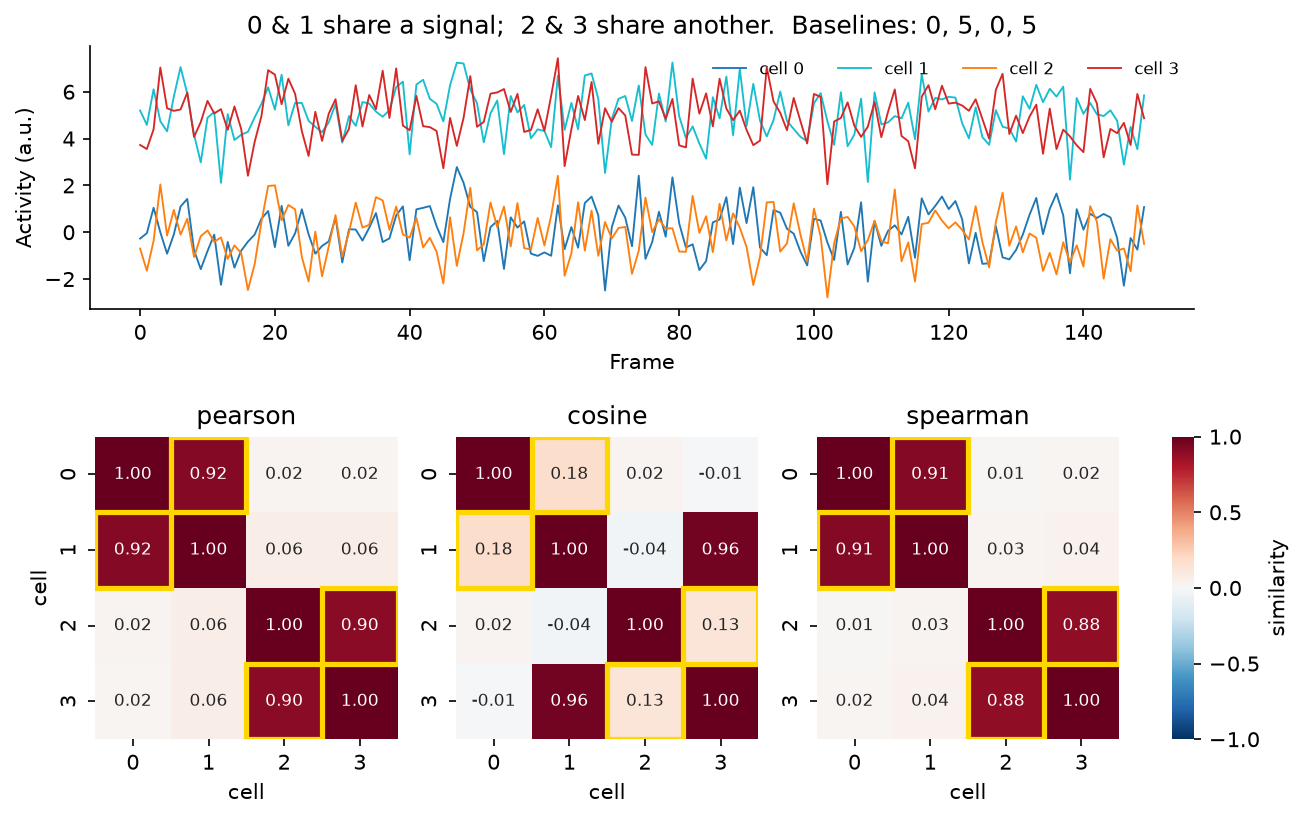

In [30]:
# Figure 4b: the same four cells, three similarity measures, three different matrices

demo_frames = demo_mask == 1  # one condition is enough to make the point
demo_matrices = [
    ("pearson", pearson_correlation(demo_traces[:, demo_frames])),
    ("cosine", cosine_similarity(demo_traces[:, demo_frames])),
    ("spearman", spearman_correlation(demo_traces[:, demo_frames])),
]

fig = plt.figure(figsize=(9.5, 6), dpi=150)
# The colourbar gets its own column, so all three matrices stay the same size
grid = fig.add_gridspec(
    2, 4, height_ratios=[1, 1.15], width_ratios=[1, 1, 1, 0.07], hspace=0.45
)
ax_cbar = fig.add_subplot(grid[1, 3])

# Top: the synthetic traces. Cells 0/1 share a signal, as do 2/3; within each pair the
# baselines differ, which is what the measures will disagree about.
ax_traces = fig.add_subplot(grid[0, :])
for cell, trace in enumerate(demo_traces):
    ax_traces.plot(
        trace[:150],
        lw=0.9,
        color=["tab:blue", "tab:cyan", "tab:orange", "tab:red"][cell],
        label=f"cell {cell}",
    )
ax_traces.legend(frameon=False, ncol=4, fontsize=8, loc="upper right")
ax_traces.set(
    xlabel="Frame",
    ylabel="Activity (a.u.)",
    title="0 & 1 share a signal;  2 & 3 share another.  Baselines: 0, 5, 0, 5",
)
sns.despine(ax=ax_traces)

# Bottom: one similarity matrix per measure. `pairwise_similarity_table` is just the
# long-format version of exactly these matrices.
for panel, (name, matrix) in enumerate(demo_matrices):
    ax = fig.add_subplot(grid[1, panel])
    sns.heatmap(
        matrix,
        vmin=-1,
        vmax=1,
        cmap="RdBu_r",
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 8},
        square=True,
        cbar=panel == 2,
        cbar_ax=ax_cbar if panel == 2 else None,
        cbar_kws={"label": "similarity"} if panel == 2 else None,
        ax=ax,
    )
    # Outline the two pairs that really do share a signal
    for i, j in [(0, 1), (1, 0), (2, 3), (3, 2)]:
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="gold", lw=2.5))
    ax.set(title=name, xlabel="cell", ylabel="cell" if panel == 0 else "")

plt.show()

The gold outlines mark the four entries that *should* be high — the pairs we built to share a
signal.

**Pearson** and **Spearman** put ≈ 0.9 inside the gold boxes and ≈ 0 everywhere else. They
recover the construction.

**Cosine gets a different answer entirely** — and not a noisier version of the same one. Its
highest off-diagonal entry, ≈ 0.96, is at **(1, 3)**, a pair sharing *no* signal, while the
gold box at (0, 1) reads ≈ 0.2. Cosine does not subtract the mean, so a large shared baseline
makes two traces point in nearly the same direction in frame-space whatever their fluctuations
do. Cells 1 and 3 both sit at baseline 5, cells 0 and 2 both at 0. Cosine has faithfully
recovered the *baseline* groups instead of the signal groups.

Look back at the top panel and notice your own eye doing the same thing: it groups the four
traces into a top pair and a bottom pair — by height, exactly cosine's mistake — when the
shared signals actually run one from each group.

None of the three measures is wrong. Cosine answers "are these two equally active?", which on
data where the baseline carries real meaning is the better question. The point is that the
answer to *"are connected neurons more similar?"* depends on a choice made long before the
connectivity analysis begins, and inheriting a prepared table means inheriting that choice
without being asked.

For now we continue with the prepared Pearson correlations.

### Are co-active neurons more likely to be connected?

Same recipe as Part 1: narrow from all coregistered pairs, to the testable ones, to the
connected ones, and see whether the distribution shifts.

In [31]:
# Same L3-IT + proofreading restriction as Part 1
corr_coreg_proofread_df = corr_coreg_df[
    np.isin(corr_coreg_df["pre_pt_root_id"], pre_root_ids)
    & np.isin(corr_coreg_df["post_pt_root_id"], post_root_ids)
]

# Pairs that are both coregistered and connected
conn_corr_df = pd.merge(
    conn_df, corr_coreg_proofread_df, on=["pre_pt_root_id", "post_pt_root_id"]
)

print(f"{len(corr_coreg_df):>6,} coregistered pairs")
print(f"{len(corr_coreg_proofread_df):>6,} of those are testable (proofread)")
print(f"{len(conn_corr_df):>6,} of those are connected")

135,622 coregistered pairs
11,286 of those are testable (proofread)
   274 of those are connected


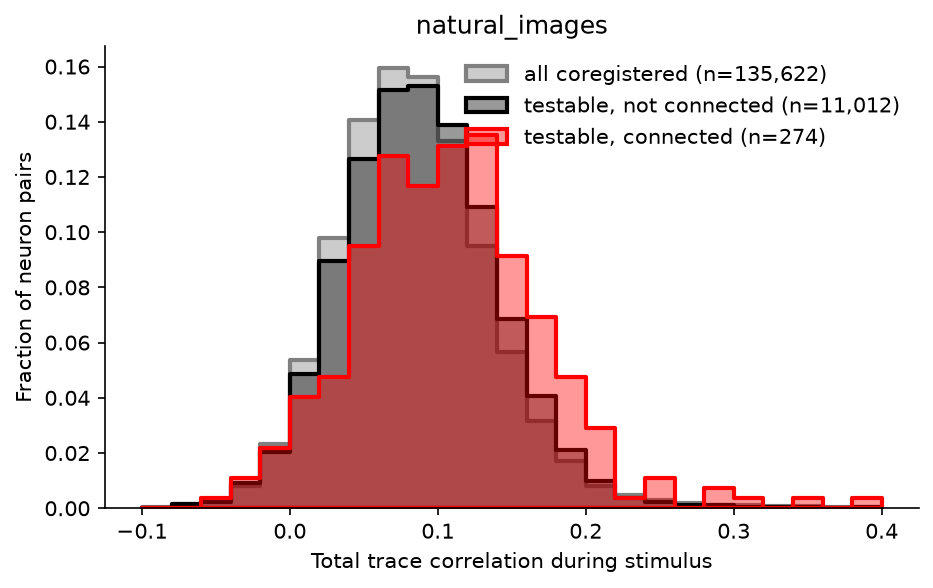

In [32]:
# Figure 5: Connected pairs are more correlated than the pairs they are drawn from
# `stat="probability"` is what makes the three populations comparable despite different N

bins = np.linspace(-0.1, 0.4, 26)

# Split the testable pairs into the two groups every test below compares
unconn_corr_df = corr_coreg_proofread_df[
    ~corr_coreg_proofread_df.index.isin(
        pd.merge(
            corr_coreg_proofread_df.reset_index(),
            conn_df,
            on=["pre_pt_root_id", "post_pt_root_id"],
        )["index"]
    )
]

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

for df, color, label in [
    (corr_coreg_df, "grey", f"all coregistered (n={len(corr_coreg_df):,})"),
    (unconn_corr_df, "k", f"testable, not connected (n={len(unconn_corr_df):,})"),
    (conn_corr_df, "r", f"testable, connected (n={len(conn_corr_df):,})"),
]:
    sns.histplot(
        df,
        x=stim,
        stat="probability",
        bins=bins,
        element="step",
        fill=True,
        alpha=0.4,
        lw=2,
        color=color,
        label=label,
        ax=ax,
    )

ax.legend(frameon=False)
ax.set(
    title=stim,
    xlabel="Total trace correlation during stimulus",
    ylabel="Fraction of neuron pairs",
)
sns.despine()
plt.show()

# Reused in Part 3, so the two figures can be read against each other
correlation_bins = bins
correlation_ylim = ax.get_ylim()

The red distribution sits to the right of the black one — but only just, and they overlap
almost entirely. The same test as in Part 1 says how reliable that shift is, and how big:

In [33]:
p, auc = compare_distributions(
    conn_corr_df[stim], unconn_corr_df[stim], "connected", "not connected"
)

connected (n=274)  vs  not connected (n=11,012)
  median          0.1052  vs    0.08662
  p             1.26e-06
  AUC              0.586   (0.5 = indistinguishable)
     a random 'connected' exceeds a random 'not connected' 58.6% of the time


Both statements are true at once, and holding them together is the whole point:

- **Reliable.** $p$ is small, so a shift this size is unlikely to be an accident of sampling.
- **Small.** AUC ≈ 0.58 — barely above the 0.5 of no difference, and nowhere near Part 1's
  distance effect. Given one connected and one unconnected pair, correlation identifies the
  connected one only slightly more often than a coin. You could not use it to predict
  connectivity.

One caveat on that $p$, which matters more here than in Part 1. Mann–Whitney assumes the
observations are independent, and our pairs are not: the 331 connected pairs come from only
59 distinct presynaptic cells, with one cell contributing 21 of them. Pairs sharing a
presynaptic cell share whatever is idiosyncratic about it, so the effective sample size is
smaller than 331 and the true $p$ is larger than the one printed. This is exactly why Part 3
does not stop here — a resampling null that respects the structure of the data is a stronger
instrument than an off-the-shelf test.

The light grey distribution is there for context: restricting from all coregistered pairs to
the testable ones barely moves it, which is reassuring — proofreading was targeted at
particular cells, but not at unusually well-correlated ones.

As in Part 1, we can turn this into a connection probability — now as a function of
activity correlation instead of distance. Correlations are not uniformly spread, so we use
**percentile bins**, which put an equal number of pairs in each.

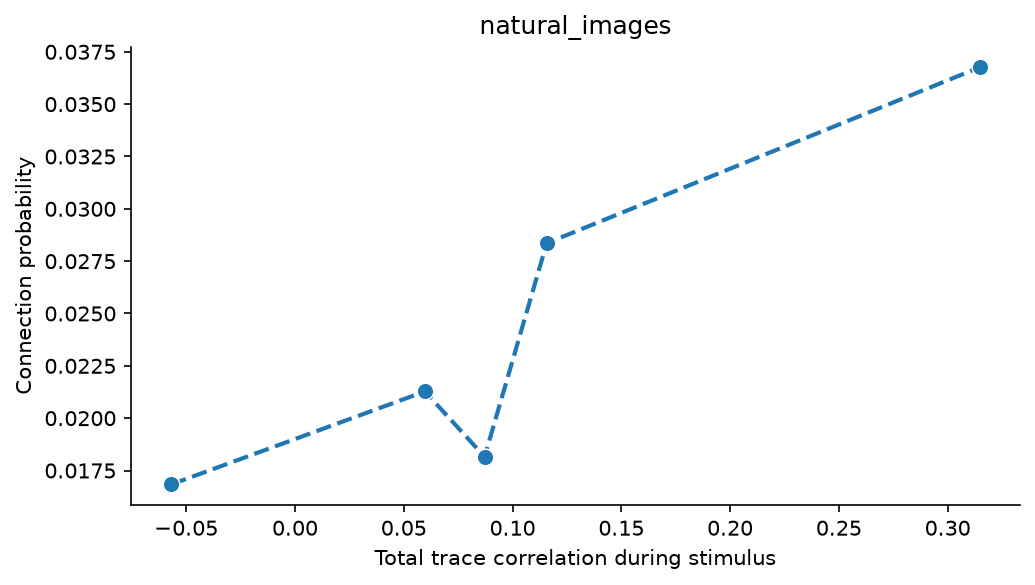

In [34]:
# Figure 6: Connection probability rises with activity correlation

bins = np.percentile(corr_coreg_proofread_df[stim], np.linspace(0, 100, 6))  # 5 bins
bin_centers = np.convolve(bins, [0.5, 0.5], mode="valid")

proofread_pair_counts = np.histogram(corr_coreg_proofread_df[stim], bins)[0]
connected_pair_counts = np.histogram(conn_corr_df[stim], bins)[0]
connection_probability = connected_pair_counts / proofread_pair_counts

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

sns.lineplot(
    x=bin_centers,
    y=connection_probability,
    lw=2,
    ls="--",
    marker="o",
    markersize=8,
    ax=ax,
)

ax.set(
    title=stim,
    xlabel="Total trace correlation during stimulus",
    ylabel="Connection probability",
)
sns.despine()
plt.tight_layout()
plt.show()

### Interim summary

For L3-IT cells:

1. Neurons closer to each other are more likely to be connected.
2. Neurons with more correlated activity during natural images are more likely to be
   connected.

## Part 3: A stronger null model

We have two results:

1. **Distance → connectivity.** Connected pairs are closer together than unconnected ones
   (AUC 0.19, medians 129 vs 319 µm).
2. **Correlation → connectivity.** Connected pairs are more correlated than unconnected ones
   (AUC 0.58, $p \approx 2 \times 10^{-6}$).

Reading these as two separate discoveries requires them to be **independent** — that
knowing a pair's distance tells you nothing about its correlation. Then each result would
contribute its own evidence, and (2) would be a genuine second predictor of connectivity.

They are not independent, for a reason that has nothing to do with wiring: **nearby neurons
in visual cortex see similar things.** Their receptive fields overlap, they receive input
from overlapping sets of thalamic and cortical afferents, and they sit in the same
orientation domain. Distance and correlation are therefore linked directly, and connectivity
is linked to both.

That opens a way for (2) to be an artefact of (1) alone:

> Connected pairs are mostly nearby pairs *(result 1)*. Nearby pairs are more correlated
> *(shared input, no wiring involved)*. Therefore connected pairs are more correlated —
> with no like-to-like connectivity rule anywhere in the story.

Every statistical claim is a comparison against a null model, whether or not you say so out
loud. Result (2) was compared against ***every testable pair is equally likely to be
connected***, and Part 1 is precisely the demonstration that this null is false. So the
comparison that produced (2) was against a null we already knew to be wrong.

### Seeing the entanglement

Rather than take the shared-input argument on faith, we can look at it. Below is the whole
correlation matrix for the coregistered L3-IT cells — every cell against every other cell,
under `natural_images`.

To bring space into the picture we need an order for the rows and columns. We pick one cell
near the middle of the population as a **reference** and sort every cell by its distance from
it. The cells at the top left of the matrix are then the ones packed around the reference, and
— being packed around the same point — close to each other too. The cells at the bottom right
sit around the edges, far from the reference and mostly far from one another.

If correlation had nothing to do with space, that ordering would leave the matrix looking like
noise.

In [35]:
# One symmetric matrix over the coregistered L3-IT cells.
# `aggfunc="mean"` because a few cells were imaged in more than one session, so some pairs
# appear twice (see the data-duplication note in the functional data notebook).
corr_l3_df = corr_coreg_df[
    corr_coreg_df["pre_pt_root_id"].isin(sub_cell_df["pt_root_id"])
    & corr_coreg_df["post_pt_root_id"].isin(sub_cell_df["pt_root_id"])
]
matrix_cells = sorted(
    set(corr_l3_df["pre_pt_root_id"]) | set(corr_l3_df["post_pt_root_id"])
)
corr_matrix = (
    corr_l3_df.pivot_table(
        index="pre_pt_root_id", columns="post_pt_root_id", values=stim, aggfunc="mean"
    )
    .reindex(index=matrix_cells, columns=matrix_cells)
    .to_numpy()
)

# Sort the cells by distance from a reference cell near the middle of the population
matrix_pos = (
    sub_cell_df.set_index("pt_root_id")
    .loc[matrix_cells, ["pt_position_trform_x", "pt_position_trform_z"]]
    .to_numpy()
)
reference = np.argmin(np.linalg.norm(matrix_pos - matrix_pos.mean(axis=0), axis=1))
distance_to_reference = np.linalg.norm(matrix_pos - matrix_pos[reference], axis=1)

corr_matrix = corr_matrix[np.ix_(*[np.argsort(distance_to_reference)] * 2)]

print(
    f"{len(matrix_cells)} cells, {np.isfinite(corr_matrix).mean():.1%} of the matrix filled"
)
print(
    f"distance from the reference cell: {distance_to_reference.min():.0f} to "
    f"{distance_to_reference.max():.0f} µm"
)

199 cells, 99.5% of the matrix filled
distance from the reference cell: 0 to 240 µm


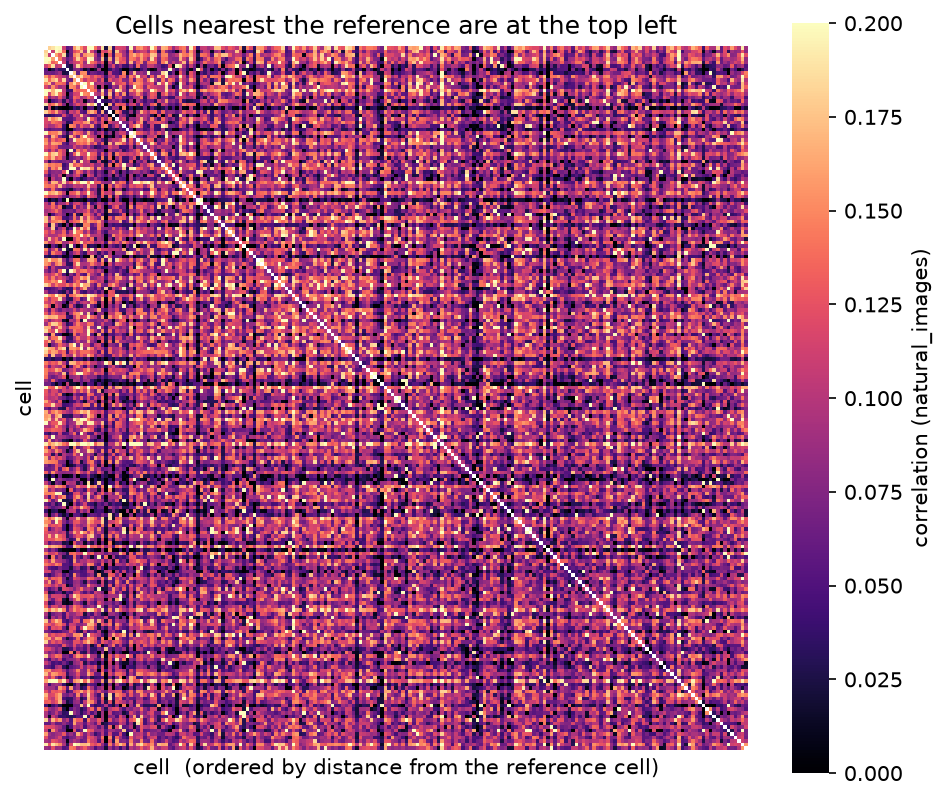

In [36]:
# Figure 7: the correlation matrix, cells ordered by distance from a reference cell

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=150)

sns.heatmap(
    corr_matrix,
    vmin=0,
    vmax=0.2,
    cmap="magma",
    square=True,
    cbar_kws={"label": f"correlation ({stim})"},
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)

ax.set(
    xlabel="cell  (ordered by distance from the reference cell)",
    ylabel="cell",
    title="Cells nearest the reference are at the top left",
)
plt.tight_layout()
plt.show()

Look at it before reading on. What stands out is *not* a spatial pattern — it is the
**stripes**: whole rows and columns brighter or darker than the rest. Some cells are simply
more correlated with everything than others, with per-cell means running from 0.03 to 0.14,
and that variation dominates the picture.

The spatial effect is in there, but it is far too small to eyeball. So we measure it, using the
same test as before: the pairs inside the 50-cell block nearest the reference against the pairs
inside the 50 farthest.

In [37]:
def block_correlations(first, last):
    """All pairwise correlations within one block of the ordered matrix."""
    block = corr_matrix[first:last, first:last]
    keep = ~np.eye(len(block), dtype=bool) & np.isfinite(block)
    return block[keep]


p, auc = compare_distributions(
    block_correlations(0, 50),
    block_correlations(-50, None),
    "50 cells nearest the reference",
    "50 cells farthest",
)

50 cells nearest the reference (n=2,450)  vs  50 cells farthest (n=2,450)
  median         0.09503  vs    0.08528
  p             3.62e-10
  AUC              0.552   (0.5 = indistinguishable)
     a random '50 cells nearest the reference' exceeds a random '50 cells farthest' 55.2% of the time


0.093 against 0.085, with $p \approx 3 \times 10^{-8}$ — a difference you would never have
found by looking at the matrix. The two blocks differ in their mean pairwise separation, 63 µm
against 223 µm, and in nothing else that we chose.

Two things to take from that. The first is a habit: a matrix plot is good for seeing what
*dominates* a dataset and unreliable for anything smaller, so reach for a statistic as soon as
the question is quantitative.

The second is the reason we are in Part 3 at all. Put that gap of 0.008 beside the one Part 2 asked us to explain: connected pairs averaged 0.109
against 0.093 for unconnected, a gap of 0.016. **Proximity alone accounts for roughly half of
it.** The confound is not a technicality to note in passing; it is the same order of magnitude
as the effect under investigation.

The honest question: **once the null model knows about distance, does the
structure–function relationship survive?**

**Discussion:** How would you build such a null model?

Our approach: generate synthetic connectomes in which connection probability depends *only*
on distance — using the curve we measured in Part 1, so the synthetic networks reproduce
the real distance dependence exactly — and check whether they also reproduce the observed
correlation of connected pairs. If they do, result (2) was proximity in disguise. If the
real connectome sits outside the range the synthetic ones cover, something beyond distance
is at work.

### One table with everything

We need distance, activity correlation, and connectivity for the same set of pairs.
`corr_coreg_proofread_df` is the most restrictive (coregistration is rare), so we merge
onto it.

In [38]:
# Base: coregistered, testable L3-IT pairs
full_df = corr_coreg_proofread_df.copy()

# + lateral distance
full_df = pd.merge(
    full_df, lateral_distance_proofread_df, on=["pre_pt_root_id", "post_pt_root_id"]
)

# + connectivity; pairs absent from conn_df are unconnected, i.e. size 0
full_df = pd.merge(
    full_df, conn_df, on=["pre_pt_root_id", "post_pt_root_id"], how="left"
).fillna(0)
full_df["connected"] = full_df["size"] > 0

print(f"{len(full_df):,} pairs, {full_df['connected'].sum():,} connected")
full_df.head(3)

11,286 pairs, 274 connected


,column,volume,pre_plane,pre_roi,post_plane,post_roi,drifting_gratings_full,drifting_gratings_windowed,locally_sparse_noise,natural_images,natural_images_12,natural_movie,spontaneous,pre_pt_root_id,post_pt_root_id,distance,size,connected
0,1,3,0,6,0,25,0.011712,-0.018059,0.177509,0.053082,0.118612,0.053856,0.061307,864691132993747701,864691132617961537,91.487462,0.0,False
1,1,3,0,6,0,27,0.054421,0.014667,0.100715,0.112722,0.078214,0.030832,0.059752,864691132993747701,864691132758875499,280.750396,0.0,False
2,1,3,0,6,0,37,0.046524,0.035209,0.127884,0.123014,0.054419,0.017720,0.062639,864691132993747701,864691132897987302,101.334086,0.0,False


### The measurement to beat

A null model can only be compared against a single number, so we compress the
structure–function result into one: the mean activity correlation of connected pairs. (Its
unconnected counterpart is there for reference — the null distribution will centre near it.)

In [39]:
full_df.groupby("connected")[stim].mean()

connected
False    0.088807
True     0.106711
Name: natural_images, dtype: float32

### Sampling distance-matched connectomes

Every pair gets a connection probability from its distance, reusing the Part 1
measurement. `np.digitize` assigns each pair to a distance bin, which we then join to the
per-bin probabilities.

*Note the `- 1`:* `np.digitize` returns 1 for the first bin, so it needs shifting to
match the 0-based `bin_id`. Pairs beyond the last bin edge (500 µm) fall outside the
table and are dropped by the merge.

In [40]:
distance_bins = np.linspace(0, 500, 101)

proofread_pair_counts = np.histogram(
    lateral_distance_proofread_df["distance"], distance_bins
)[0]
connected_pair_counts = np.histogram(conn_dist_df["distance"], distance_bins)[0]

connection_probability_df = pd.DataFrame(
    {
        "bin_id": np.arange(len(distance_bins) - 1),
        "bin_start": distance_bins[:-1],
        "bin_end": distance_bins[1:],
        "connection_probability": connected_pair_counts / proofread_pair_counts,
    }
)

full_df["bin_id"] = np.digitize(full_df["distance"], distance_bins) - 1
full_df = pd.merge(full_df, connection_probability_df, on="bin_id")

print(f"{len(full_df):,} pairs within {distance_bins[-1]:.0f} µm")
connection_probability_df.head(3)

11,286 pairs within 500 µm


,bin_id,bin_start,bin_end,connection_probability
0,0,0.0,5.0,0.062257
1,1,5.0,10.0,0.084354
2,2,10.0,15.0,0.046281


**Task:** Sample one connectome. Use
[`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html),
which takes the entries to sample from (`a`), their probabilities (`p`, must sum to 1),
and how many to draw (`size`). Draw as many connections as we actually observe.

In [41]:
full_sampled_df = full_df.copy()

probabilities = (
    full_df["connection_probability"] / full_df["connection_probability"].sum()
)
sampled_idx = np.random.choice(
    a=full_df.index,
    size=int(full_df["connected"].sum()),  # as many edges as we actually observe
    replace=True,
    p=probabilities,
)

full_sampled_df["connected_sampled"] = False
full_sampled_df.loc[sampled_idx, "connected_sampled"] = True

full_sampled_df.groupby("connected_sampled")[stim].mean()

connected_sampled
False    0.089179
True     0.091803
Name: natural_images, dtype: float32

One sample is noise. Repeating it 10,000 times gives the null *distribution* of the mean
correlation of connected pairs.

In [42]:
sampled_means = []

for _ in tqdm.tqdm(range(10_000), mininterval=2.0):
    sampled_idx = np.random.choice(
        full_df.index,
        p=full_df["connection_probability"] / full_df["connection_probability"].sum(),
        size=int(full_df["connected"].sum()),
    )
    sampled_means.append(full_df.loc[sampled_idx, stim].mean())

sampled_means = np.array(sampled_means)  # one entry per sampled connectome
sampled_means[:3]

100%|██████████| 10000/10000 [00:07<00:00, 1345.73it/s]


array([0.09338363, 0.09791849, 0.09357142], dtype=float32)

Because we built the null distribution by sampling rather than from a formula, we can read
the $p$-value straight off it — no distributional assumption at all. Counting how many
synthetic connectomes were at least as extreme as the real one *is* evaluating
$\Pr(T \ge t_{\text{obs}} \mid H_0)$:

$$\hat p \;=\; \frac{1 + \#\{b : T_b \ge t_{\text{obs}}\}}{1 + B}$$

for $B$ samples. The $+1$ s matter: without them a result more extreme than all $B$ samples
reports $\hat p = 0$, claiming infinite confidence from finite sampling. With them the
smallest value reportable from 10,000 samples is $1/10{,}001 \approx 10^{-4}$, which is an
honest floor.
*(Phipson & Smyth, [Stat. Appl. Genet. Mol. Biol. 9:39, 2010](https://doi.org/10.2202/1544-6115.1585).)*

A **Z-score** is the complementary summary. The 10,000 synthetic connectomes give a cloud of
possible values for our statistic — the mean correlation of connected pairs — with a centre
and a width. The Z-score measures how far the *real* connectome's value sits from that
centre, in units of that width:

$$Z \;=\; \frac{t_{\text{obs}} - \operatorname{mean}(T_{\text{null}})}{\operatorname{sd}(T_{\text{null}})}$$

So $Z = 3$ means the real connectome landed three null standard deviations above the typical
synthetic one. It answers the same question as $\hat p$ in a different currency, and it has
one practical advantage: $\hat p$ bottoms out at $1/(B+1)$ once *no* synthetic connectome
reaches the observed value, whereas $Z$ keeps growing and so can still tell a marginal result
from an overwhelming one.

**Task:** Compute both, from `sampled_means.mean()` and `sampled_means.std()`.

In [43]:
observed_mean = full_df[full_df["connected"]][stim].mean()

zscore = (observed_mean - sampled_means.mean()) / sampled_means.std()

n_at_least_as_extreme = int((sampled_means >= observed_mean).sum())
p_empirical = (1 + n_at_least_as_extreme) / (1 + len(sampled_means))

print(f"observed    {observed_mean:.4f}")
print(f"null mean   {sampled_means.mean():.4f}")
print(f"null std    {sampled_means.std():.4f}")
print(f"Z-score     {zscore:.2f}")
print(
    f"p (1-sided) {p_empirical:.2g}   "
    f"({n_at_least_as_extreme} of {len(sampled_means):,} samples reached it)"
)

observed    0.1067
null mean   0.0923
null std    0.0033
Z-score     4.32
p (1-sided) 0.0001   (0 of 10,000 samples reached it)


Figure 8 stacks the two things being compared, sharing an x-axis so the widths can be read
against each other, and each panel carries its own means.

**Top:** the correlations of individual pairs — the Figure 5 distributions, greyed, on the
same bins and the same y-limit.
**Bottom:** the distribution of the *mean* correlation across 10,000 distance-matched
synthetic connectomes.

The difference in width is the point. Averaging 331 pairs shrinks the sampling spread by
roughly $\sqrt{331}$, about eighteen-fold, so the same red-to-blue gap that is invisible
against the top panel is enormous against the bottom one. That is not sleight of hand: it is
the honest statement that we can locate an *average* precisely while barely distinguishing
individual pairs at all.

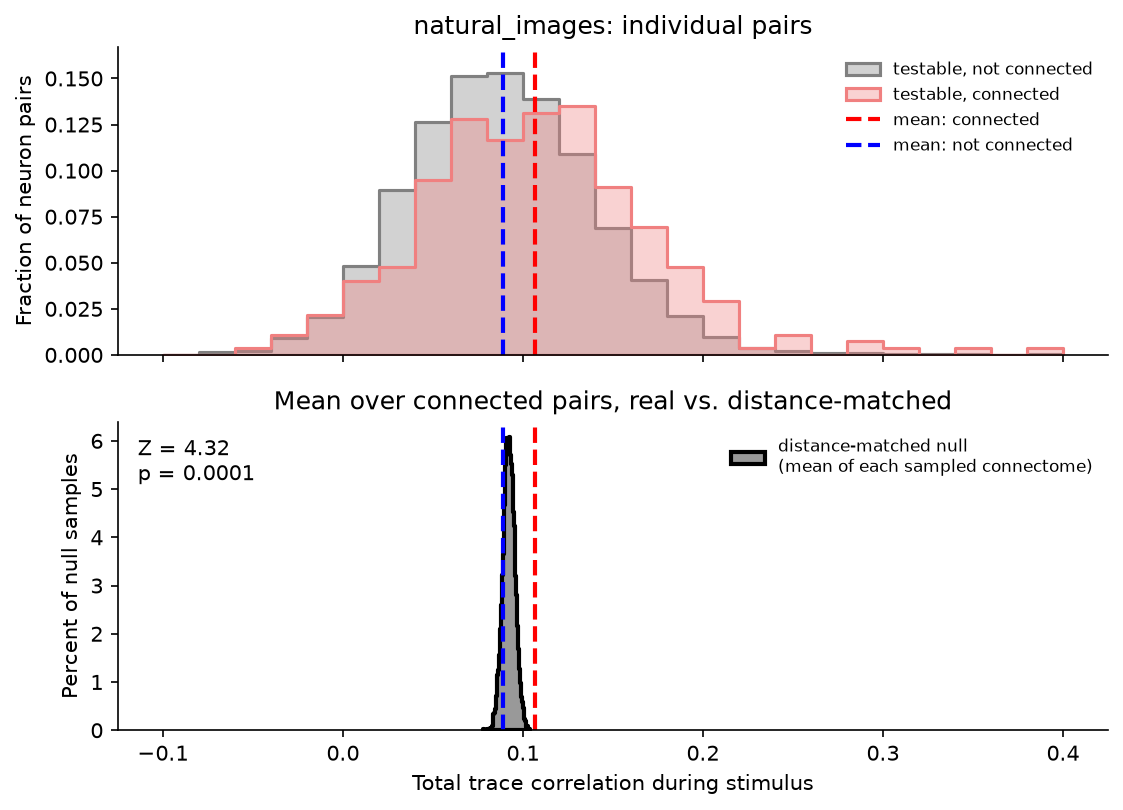

In [44]:
# Figure 8: the observed shift (top) against the distance-matched null of the mean (bottom)

connected_mean = conn_corr_df[stim].mean()
unconnected_mean = unconn_corr_df[stim].mean()
zscore = (connected_mean - sampled_means.mean()) / sampled_means.std()

fig, (ax_pairs, ax_null) = plt.subplots(
    2, 1, figsize=(7.5, 5.5), dpi=150, sharex=True, height_ratios=[1, 1]
)

# Top: individual pairs, as in Figure 5
for df, color, label in [
    (unconn_corr_df, "grey", "testable, not connected"),
    (conn_corr_df, "lightcoral", "testable, connected"),
]:
    sns.histplot(
        df,
        x=stim,
        stat="probability",
        bins=correlation_bins,
        element="step",
        fill=True,
        alpha=0.35,
        lw=1.5,
        color=color,
        label=label,
        ax=ax_pairs,
    )
ax_pairs.set_ylim(correlation_ylim)

# Bottom: the null distribution of the mean
sns.histplot(
    x=sampled_means,
    stat="percent",
    bins=51,
    element="step",
    fill=True,
    alpha=0.4,
    lw=2,
    color="k",
    label="distance-matched null\n(mean of each sampled connectome)",
    ax=ax_null,
)

# The same two means, drawn in both panels; labelled once, in the top panel
for ax, label in [(ax_pairs, True), (ax_null, False)]:
    ax.axvline(
        connected_mean,
        color="r",
        ls="--",
        lw=2,
        label="mean: connected" if label else None,
    )
    ax.axvline(
        unconnected_mean,
        color="b",
        ls="--",
        lw=2,
        label="mean: not connected" if label else None,
    )
    ax.legend(frameon=False, fontsize=8, loc="upper right")

ax_null.text(
    0.02,
    0.95,
    f"Z = {zscore:.2f}\np = {p_empirical:.2g}",
    transform=ax_null.transAxes,
    va="top",
)

ax_pairs.set(title=f"{stim}: individual pairs", ylabel="Fraction of neuron pairs")
ax_null.set(
    title="Mean over connected pairs, real vs. distance-matched",
    xlabel="Total trace correlation during stimulus",
    ylabel="Percent of null samples",
)
sns.despine()
plt.tight_layout()
plt.show()

## Summary

For L3-IT cells in V1DD:

1. **Distance predicts connectivity.** Connection probability falls steeply with lateral
   separation between somas.
2. **Activity correlation predicts connectivity.** During natural images, connected pairs
   are more correlated than testable pairs overall.
3. **The second is not just the first.** A null model that reproduces the distance
   dependence exactly still does not reproduce the correlation of connected pairs
   (Z ≈ 4.2, $\hat p \sim 10^{-4}$ — at the floor of what 10,000 samples can resolve).
   Co-activity carries information about connectivity beyond proximity.

Read the effect sizes next to the $p$-values, because they tell different stories. Both
comparisons return an overwhelming $p$, but distance is a *large* effect — AUC ≈ 0.19, so of
a connected and an unconnected pair the connected one is the closer about four times in five
— while correlation is *reliable but small*: AUC ≈ 0.58, barely above the 0.5 of no
difference. Correlation could not be used to predict connectivity even though its mean shift
is firmly established. A robust group difference and a useful predictor are not the same
claim, and conflating them is the most common way results like this get oversold.

Three habits worth carrying into a project:

- **Restrict to what you can measure.** Every comparison above is against *proofread*
  pairs, not all pairs. Unproofread axons make absence of a connection uninterpretable.
- **Name your null model.** Every claim of "more than chance" hides an assumption about what
  chance means. Writing it down turns an invisible assumption into a testable one — and in
  Part 3, changing it from "uniform" to "distance-matched" changed the question entirely.
- **Separate reliable from large.** A p-value or Z-score answers *is this real*. An effect
  size answers *does it matter*. They are different questions and both need asking.

### Exercises

The module fixed one stimulus condition, one similarity measure, and one cell type to keep
the logic visible. Each of these relaxes one of those choices.

**1. Are the stimulus conditions separate experiments?** If pairwise correlations under
drifting gratings and under natural movies agree, we effectively have one measurement; if
they disagree, we have several, and the result may depend on which we picked. Plot
`corr_coreg_df[stimulus_conditions].corr()` as a heatmap (`sns.heatmap`, `vmin=0`,
`vmax=0.5`). What do you expect before you run it?

**2. Overlay the correlation distributions** for all seven conditions on one axis, as in
Figure 5. Which condition drives the highest correlations overall — and is that the same
as the one that best predicts connectivity?

**3. Repeat Part 3 for every condition.** Sampling the null once per stimulus gives a
Z-score per condition. Rank them. Two things to watch: `spontaneous` is a grey screen, not
a visual stimulus, and `natural_images` / `natural_images_12` are near-duplicates whose
Z-scores disagree — before reading the ranking as biology, check whether the conditions
differ in the *spread* of their correlations, since Z scales inversely with that.

**4. Change what "similar" means.** Rebuild the correlation table from the raw sessions with
a different measure and rerun Parts 2 and 3 on it. Take the loading code from
[Functional Data Cell-Cell Correlations.ipynb](../supplement/Functional%20Data%20Cell-Cell%20Correlations.ipynb)
— you need `load_session_dff` and `get_combined_stimulus_map` for one session — then:

```python
from functional_similarity import pairwise_similarity_table, cosine_similarity

corr_df = pairwise_similarity_table(
    session_data["dff"], stim_mask, stim_map, metric=cosine_similarity
)
```

and merge coregistration onto it as that notebook's final section does. The most interesting
variant is **signal correlation**: average each cell's response within each stimulus first,
then correlate those averages across stimuli (`signal_correlation`). That measures agreement
about *what the cells prefer* rather than moment-to-moment co-fluctuation, which is much
closer to the like-to-like hypothesis Part 2 set out to test. Does Z go up or down?

**5. Break the null model.** It samples pairs independently, so it does not preserve how
many outgoing connections each presynaptic cell has — and the observed connections are
concentrated in a minority of cells. Build a null that samples each presynaptic cell's
connections separately, preserving its out-degree. Does Z survive?

**6. Beyond this module.** Repeat the analysis for another cell type or across types
(L3-IT → PTC); add depth or full 3D distance to the null model; weight connections by
summed synapse size instead of treating them as binary; or use the per-synapse
`synaptictargetlabel` from the CCM feature matrix to ask whether the correlation effect
depends on *where* on the dendrite the synapse lands.